In [1]:
import pandas as pd

df = pd.read_csv("../data/raw/train.csv", encoding='cp932')

print("=== shape ===")
print(df.shape)

print("\n=== dtypes ===")
print(df.dtypes)

print("\n=== head(10) ===")
df.head(10)

=== shape ===
(1322, 1559)

=== dtypes ===
sample number       int64
species number      int64
樹種                 object
含水率               float64
9993.76781        float64
                   ...   
4015.24982        float64
4011.39271        float64
4007.5356         float64
4003.6785         float64
3999.82139        float64
Length: 1559, dtype: object

=== head(10) ===


,sample number,species number,樹種,含水率,9993.76781,9989.9107,9986.05359,9982.19648,9978.33937,9974.48227,...,4034.53536,4030.67826,4026.82115,4022.96404,4019.10693,4015.24982,4011.39271,4007.5356,4003.6785,3999.82139
0,1,1,イチョウ,216.129032,0.41485,0.41465,0.41463,0.41476,0.41481,0.41470,...,1.25104,1.24925,1.24145,1.23620,1.23384,1.22981,1.22818,1.23087,1.23354,1.23219
1,2,1,イチョウ,210.752688,0.42049,0.42040,0.42049,0.42053,0.42038,0.42010,...,1.21929,1.21611,1.21565,1.21745,1.21680,1.21205,1.21074,1.21508,1.21901,1.21846
2,3,1,イチョウ,205.913979,0.41040,0.41045,0.41047,0.41028,0.41000,0.40989,...,1.17471,1.17147,1.16611,1.16633,1.16998,1.16955,1.16200,1.15341,1.15139,1.15403
3,4,1,イチョウ,201.075269,0.40080,0.40061,0.40031,0.40008,0.39993,0.39991,...,1.11271,1.11339,1.11115,1.10965,1.11017,1.11165,1.11426,1.11787,1.11849,1.11328
4,5,1,イチョウ,196.236559,0.38792,0.38814,0.38825,0.38817,0.38798,0.38778,...,1.05617,1.05596,1.05760,1.06014,1.06240,1.06566,1.06962,1.07056,1.06459,1.05612
5,6,1,イチョウ,191.397850,0.37605,0.37619,0.37610,0.37594,0.37591,0.37584,...,1.00923,1.00915,1.00917,1.01011,1.00755,1.00305,1.00307,1.00513,1.00353,1.00268
6,7,1,イチョウ,186.559140,0.36943,0.36942,0.36944,0.36940,0.36924,0.36904,...,0.98419,0.98198,0.98079,0.97935,0.97672,0.97745,0.98114,0.98187,0.97675,0.96679
7,8,1,イチョウ,182.258064,0.35676,0.35694,0.35678,0.35641,0.35612,0.35595,...,0.94364,0.94529,0.94801,0.94870,0.94640,0.94542,0.94793,0.94854,0.94314,0.93515
8,9,1,イチョウ,177.419355,0.34200,0.34220,0.34230,0.34233,0.34235,0.34228,...,0.89318,0.89206,0.89329,0.89587,0.89890,0.90336,0.90513,0.90319,0.90169,0.89914
9,10,1,イチョウ,173.118280,0.32473,0.32473,0.32448,0.32433,0.32443,0.32460,...,0.85973,0.85663,0.85428,0.85479,0.85579,0.85535,0.85645,0.85998,0.86197,0.86135


In [7]:

# 各樹種ごとのレコード数
record_counts = df.groupby('樹種')['sample number'].count().reset_index()
record_counts.columns = ['樹種', 'レコード数']
record_counts = record_counts.sort_values('レコード数', ascending=False).reset_index(drop=True)
print(f"樹種数: {len(record_counts)}")
record_counts


樹種数: 13


,樹種,レコード数
0,トチ,183
1,ヒノキ,141
2,ベイスギ,112
3,ウォールナット,110
4,ナラ,107
5,スプルース,97
6,イチョウ,94
7,ベイマツ,93
8,クリ,91
9,チェリー,88


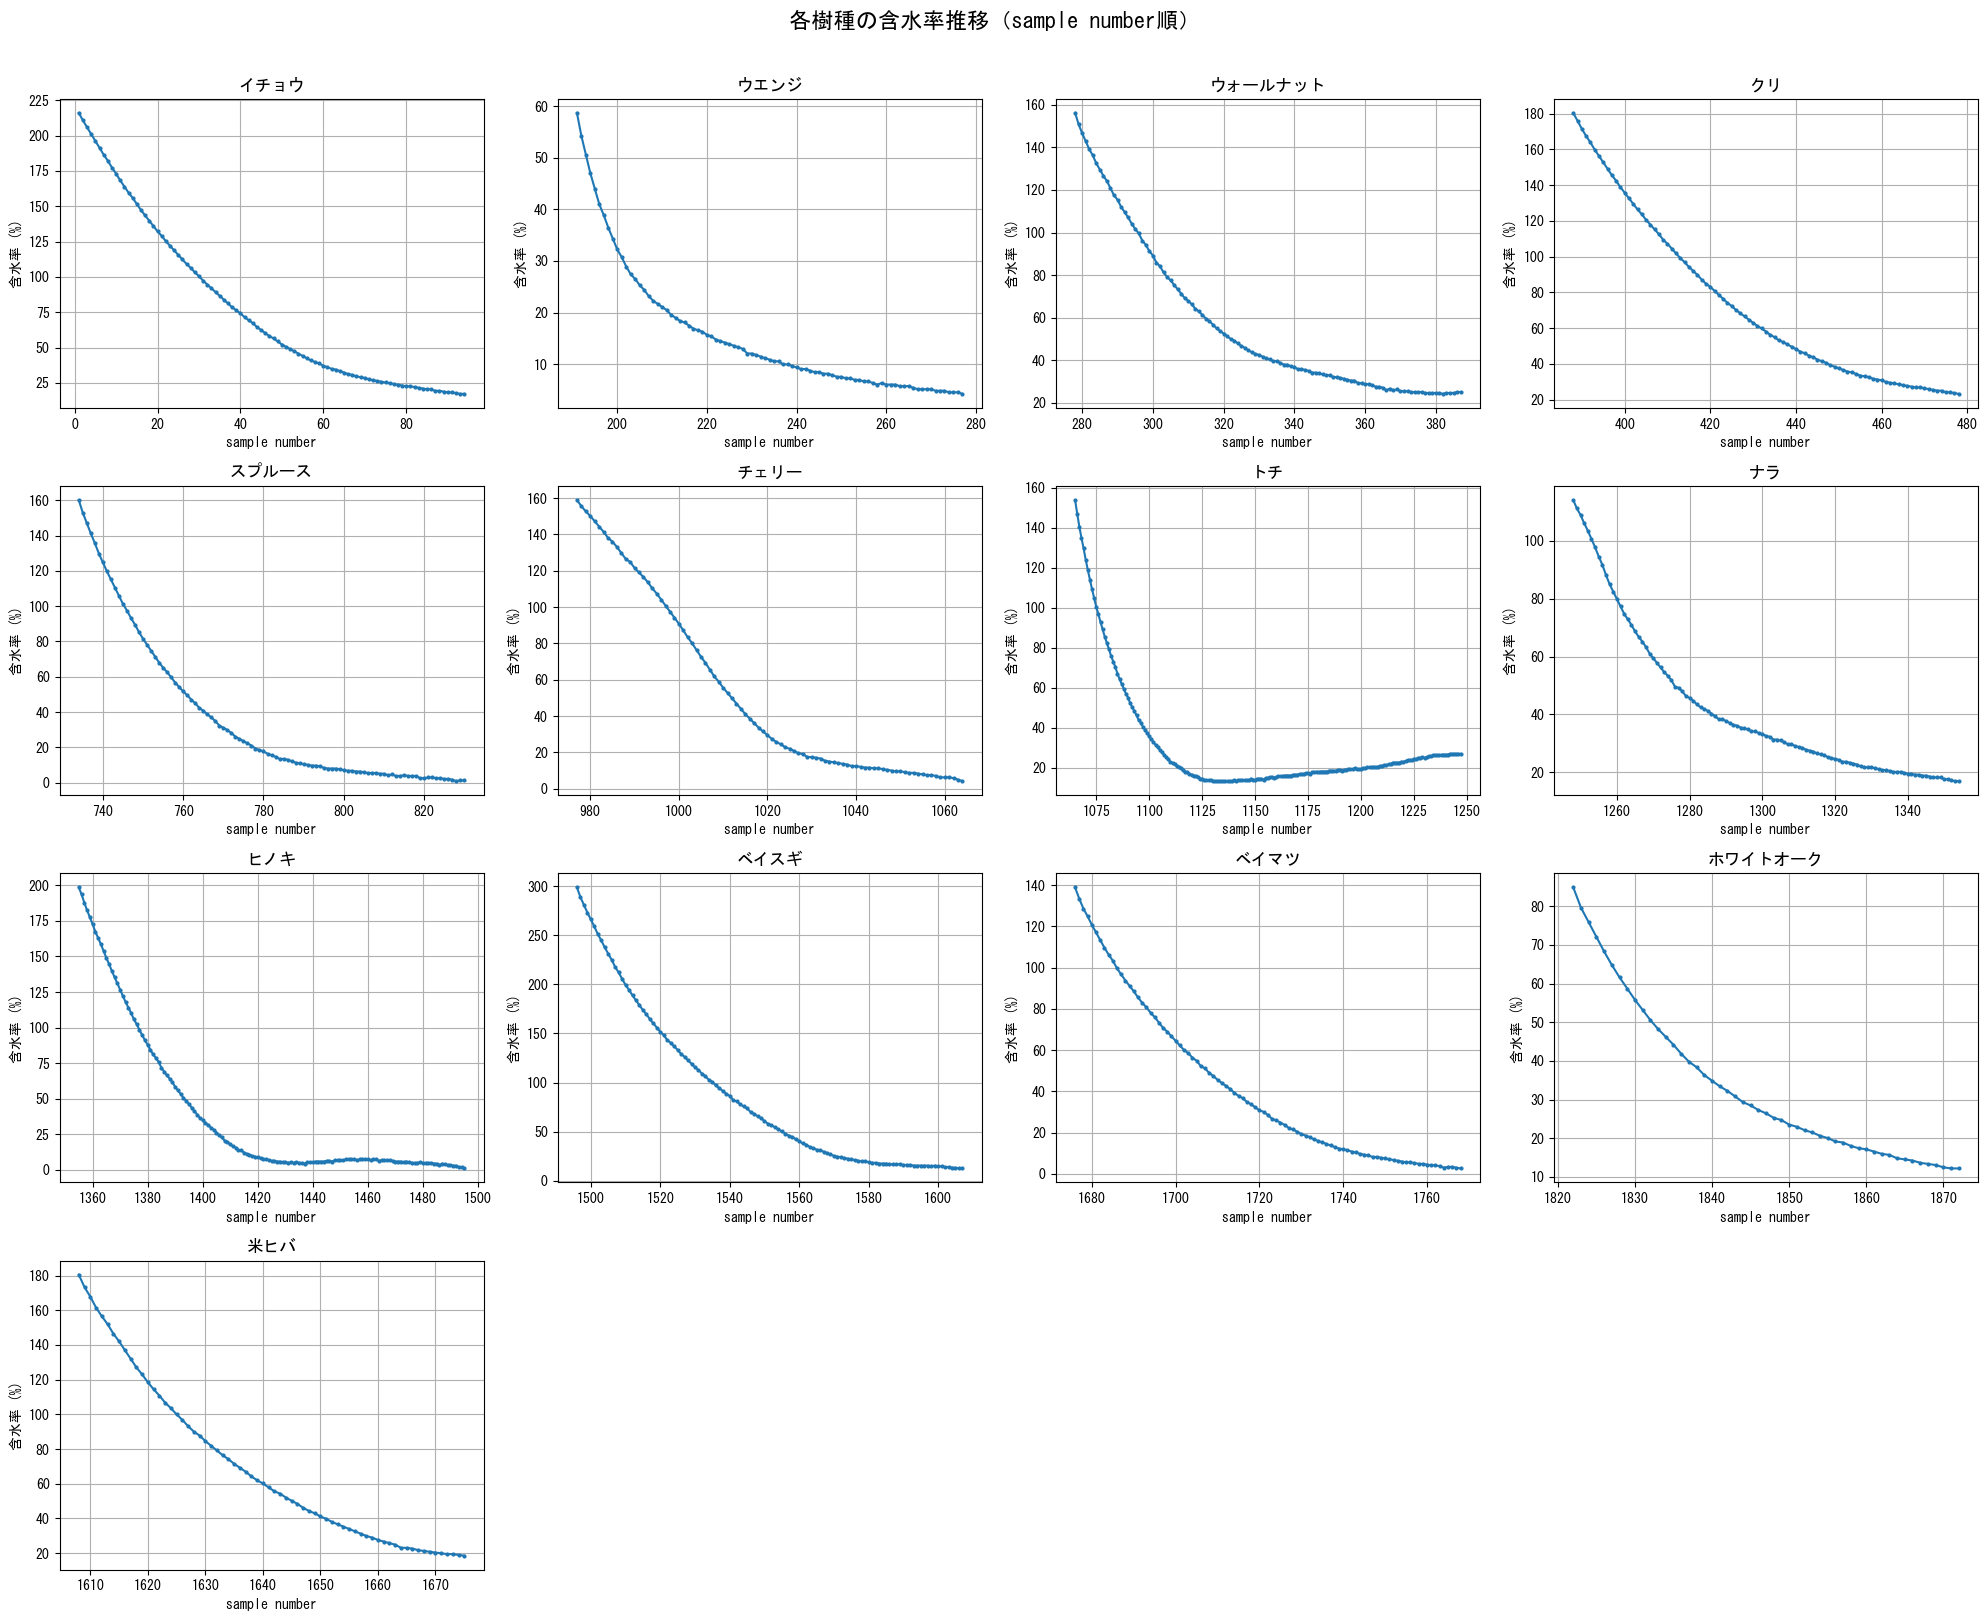

In [8]:

import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'MS Gothic'  # 日本語フォント

species_list = df['樹種'].unique()
n = len(species_list)
cols = 4
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(20, rows * 4))
axes = axes.flatten()

for i, species in enumerate(sorted(species_list)):
    subset = df[df['樹種'] == species].sort_values('sample number')
    axes[i].plot(subset['sample number'], subset['含水率'], marker='o', markersize=2)
    axes[i].set_title(species)
    axes[i].set_xlabel('sample number')
    axes[i].set_ylabel('含水率 (%)')
    axes[i].grid(True)

# 余ったaxesを非表示
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('各樹種の含水率推移（sample number順）', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()


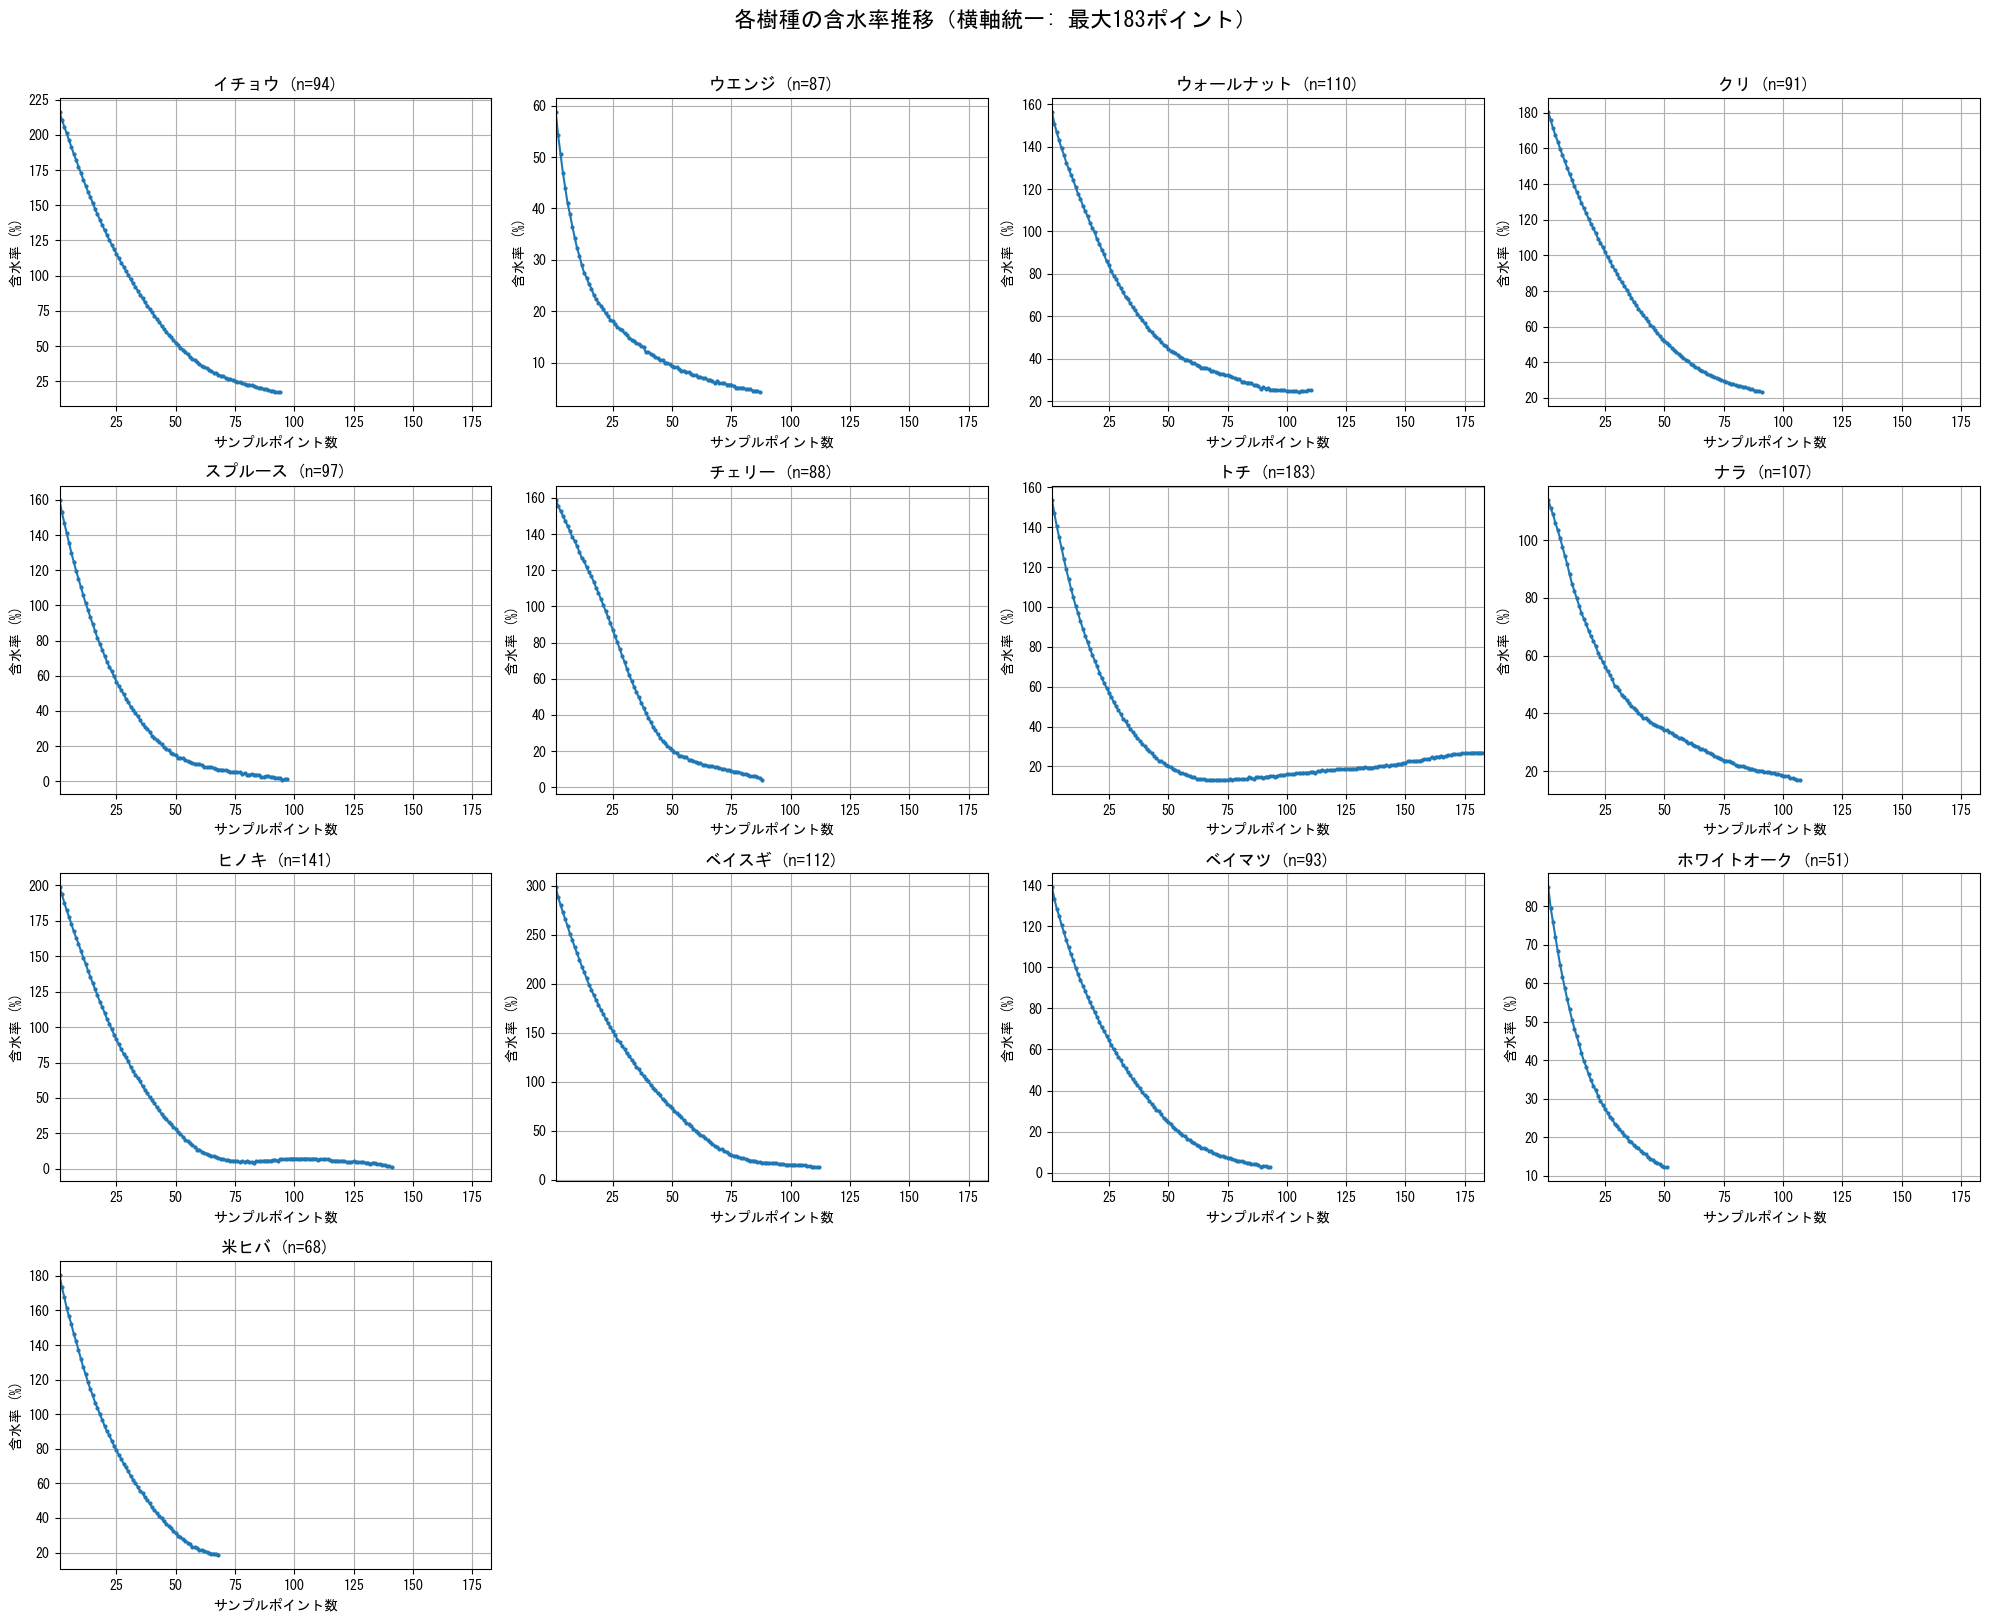

In [9]:

# 各樹種のサンプルポイント数の最大値を算出
max_points = df.groupby('樹種').size().max()

fig, axes = plt.subplots(rows, cols, figsize=(20, rows * 4))
axes = axes.flatten()

for i, species in enumerate(sorted(species_list)):
    subset = df[df['樹種'] == species].sort_values('sample number').reset_index(drop=True)
    x = subset.index + 1  # 1始まりのサンプルポイント数
    axes[i].plot(x, subset['含水率'], marker='o', markersize=2)
    axes[i].set_title(f"{species} (n={len(subset)})")
    axes[i].set_xlabel('サンプルポイント数')
    axes[i].set_ylabel('含水率 (%)')
    axes[i].set_xlim(1, max_points)
    axes[i].grid(True)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle(f'各樹種の含水率推移（横軸統一: 最大{max_points}ポイント）', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()


In [10]:

import numpy as np

# スペクトル列の取得
spectrum_cols = [c for c in df.columns if c not in ['sample number', 'species number', '樹種', '含水率']]
spectrum_cols_float = np.array([float(c) for c in spectrum_cols])

# 10cm⁻¹ごとのビンを作成（4000〜10000）
bins = np.arange(4000, 10010, 10)

# 各ビンに対応する列を特定
bin_col_map = {}
for i in range(len(bins) - 1):
    low, high = bins[i], bins[i + 1]
    mask = (spectrum_cols_float >= low) & (spectrum_cols_float < high)
    matched = [spectrum_cols[j] for j, m in enumerate(mask) if m]
    if matched:
        bin_col_map[f"{int(low)}-{int(high)}"] = matched

print(f"ビン数: {len(bin_col_map)}")

# 各サンプルごとにビンの平均値を算出
df_bin_mean = df[['sample number', 'species number', '樹種', '含水率']].copy()

for bin_label, cols in bin_col_map.items():
    df_bin_mean[bin_label] = df[cols].mean(axis=1)

# CSVに保存
output_path = "data/spectrum_bin_mean.csv"
df_bin_mean.to_csv(output_path, index=False, encoding='utf-8-sig')
print(f"保存完了: {output_path}")
print(f"shape: {df_bin_mean.shape}")
df_bin_mean.iloc[:5, :8]


ビン数: 600


C:\Users\keisu\AppData\Local\Temp\ipykernel_13812\3599732675.py:25: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_bin_mean[bin_label] = df[cols].mean(axis=1)
C:\Users\keisu\AppData\Local\Temp\ipykernel_13812\3599732675.py:25: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_bin_mean[bin_label] = df[cols].mean(axis=1)
C:\Users\keisu\AppData\Local\Temp\ipykernel_13812\3599732675.py:25: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance

保存完了: data/spectrum_bin_mean.csv
shape: (1322, 604)


,sample number,species number,樹種,含水率,4000-4010,4010-4020,4020-4030,4030-4040
0,1,1,イチョウ,216.129032,1.232205,1.230610,1.238825,1.249373
1,2,1,イチョウ,210.752688,1.217045,1.213197,1.216550,1.219123
2,3,1,イチョウ,205.913979,1.152400,1.167177,1.166220,1.171870
3,4,1,イチョウ,201.075269,1.118180,1.112027,1.110400,1.112030
4,5,1,イチョウ,196.236559,1.067575,1.065893,1.058870,1.055757


C:\Users\keisu\AppData\Local\Temp\ipykernel_13812\278320660.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  subset['point'] = subset.index + 1


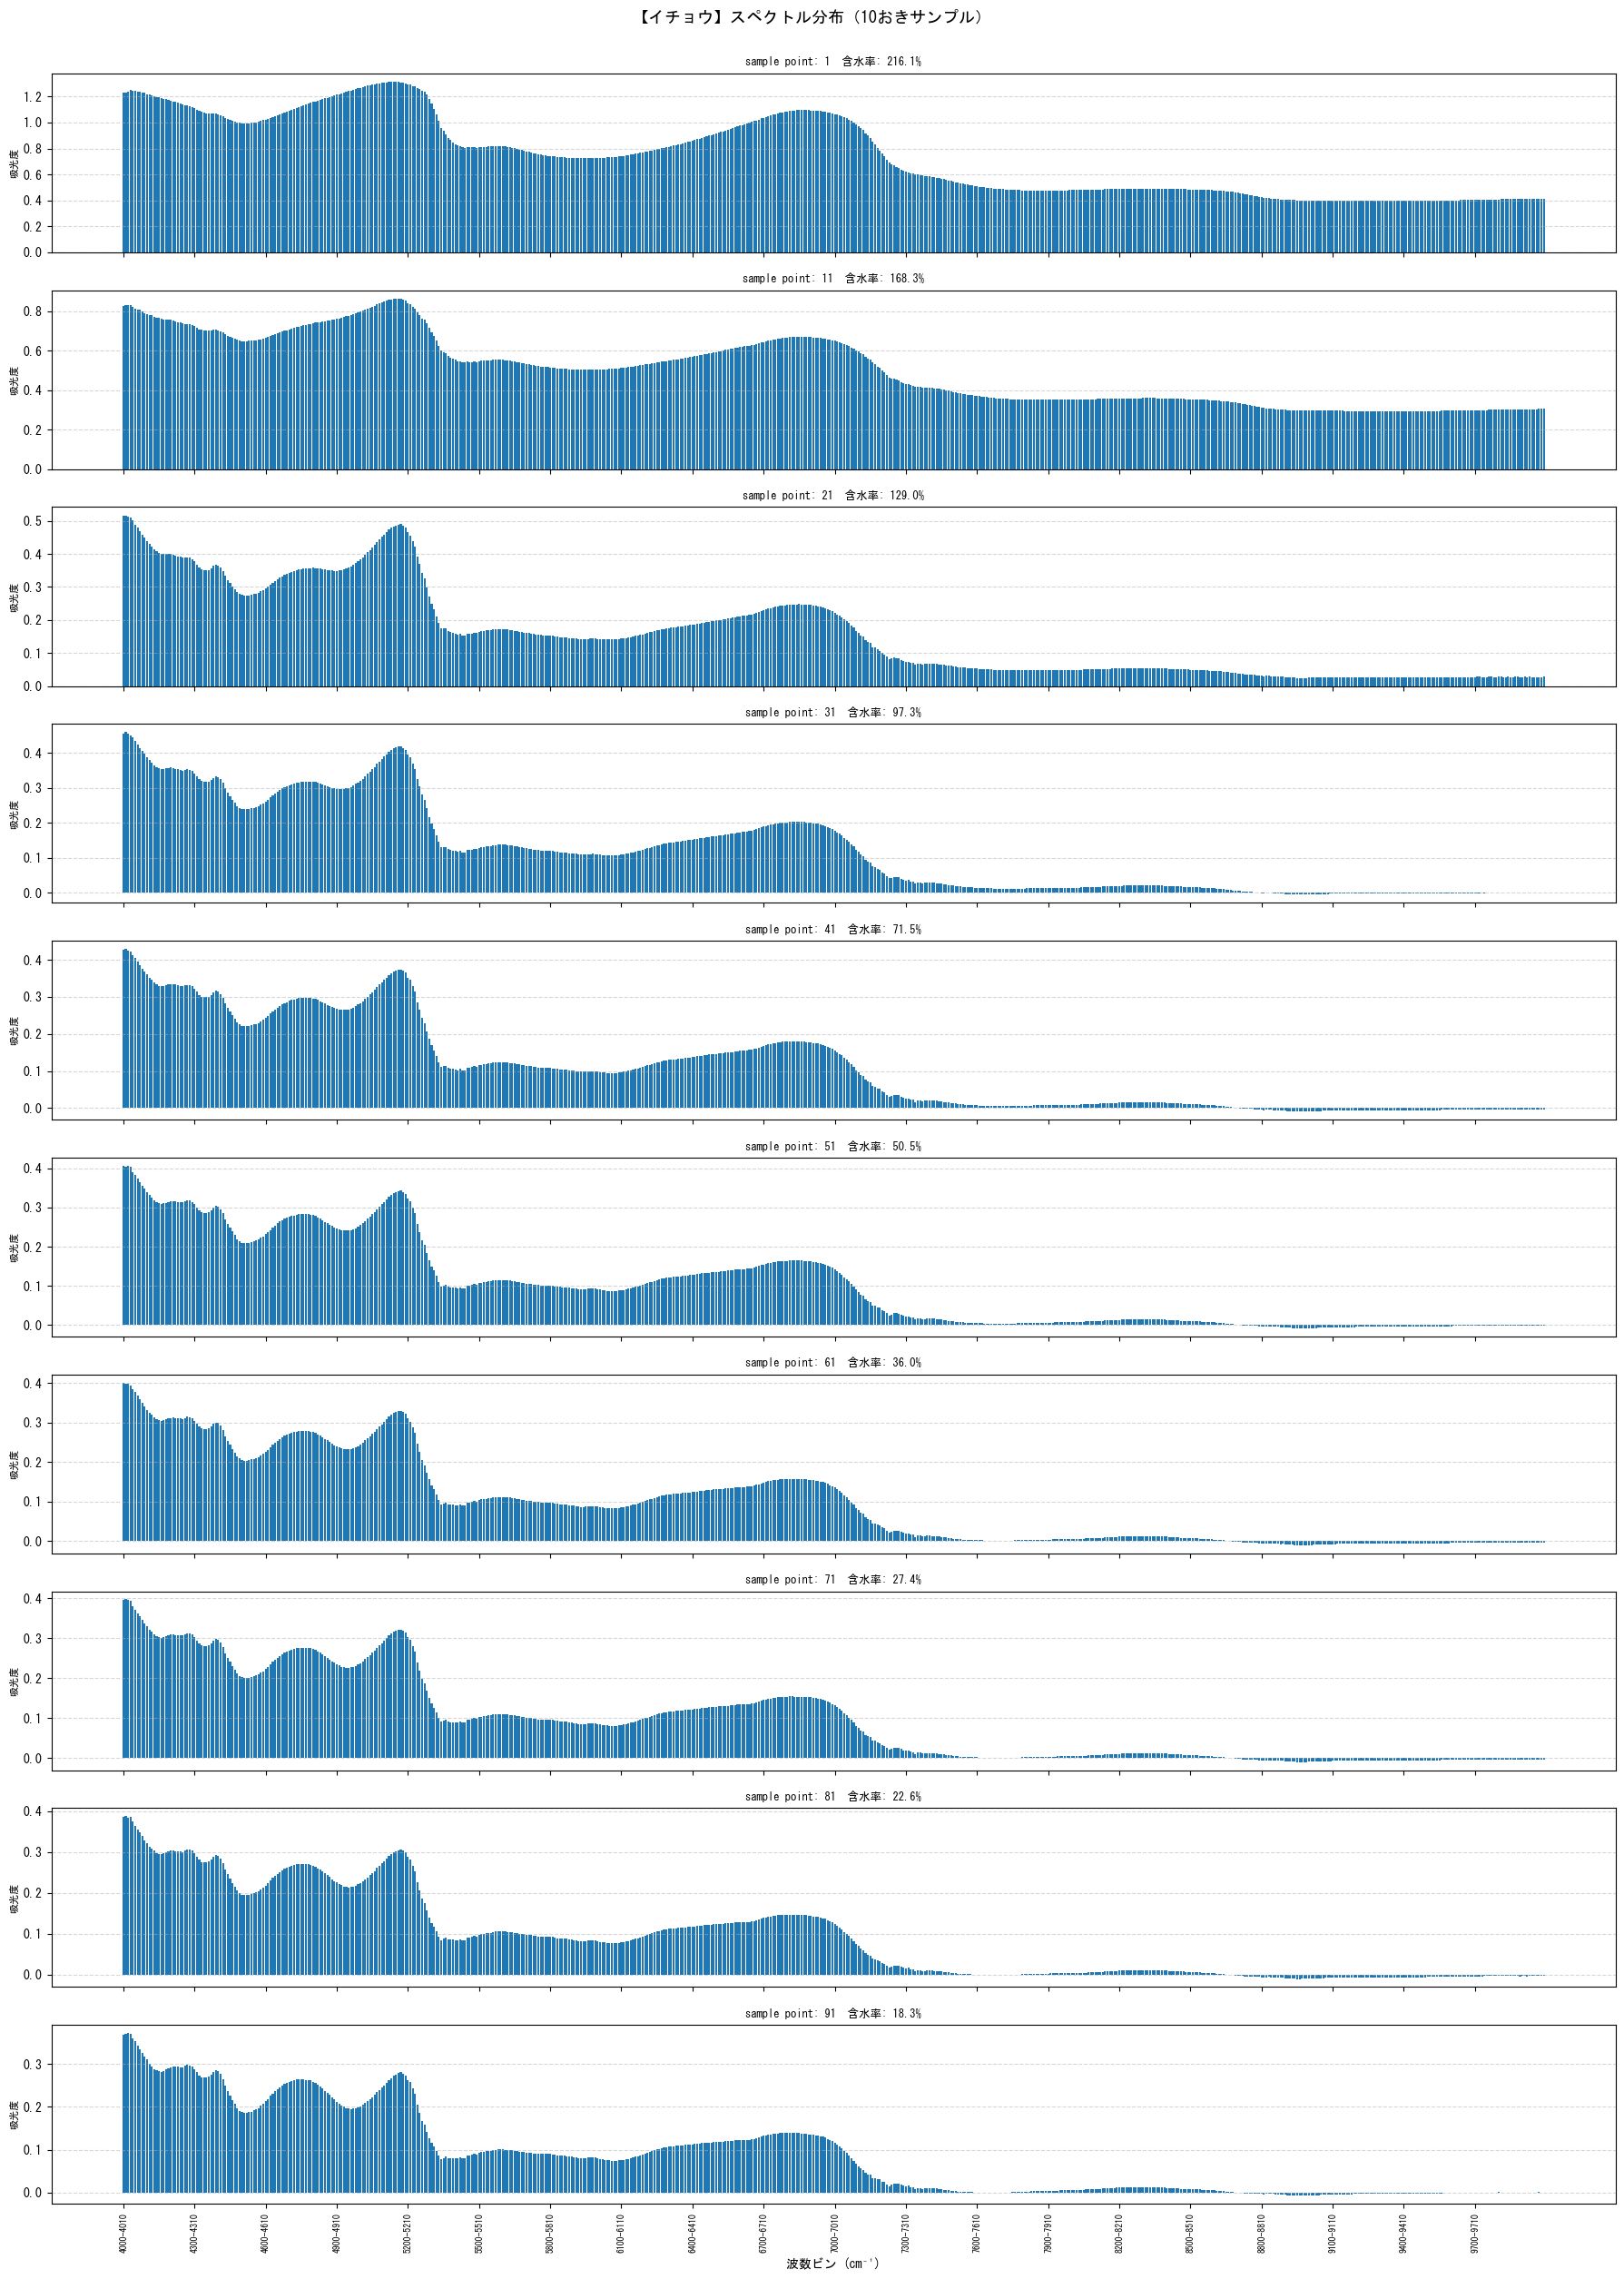

C:\Users\keisu\AppData\Local\Temp\ipykernel_13812\278320660.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  subset['point'] = subset.index + 1


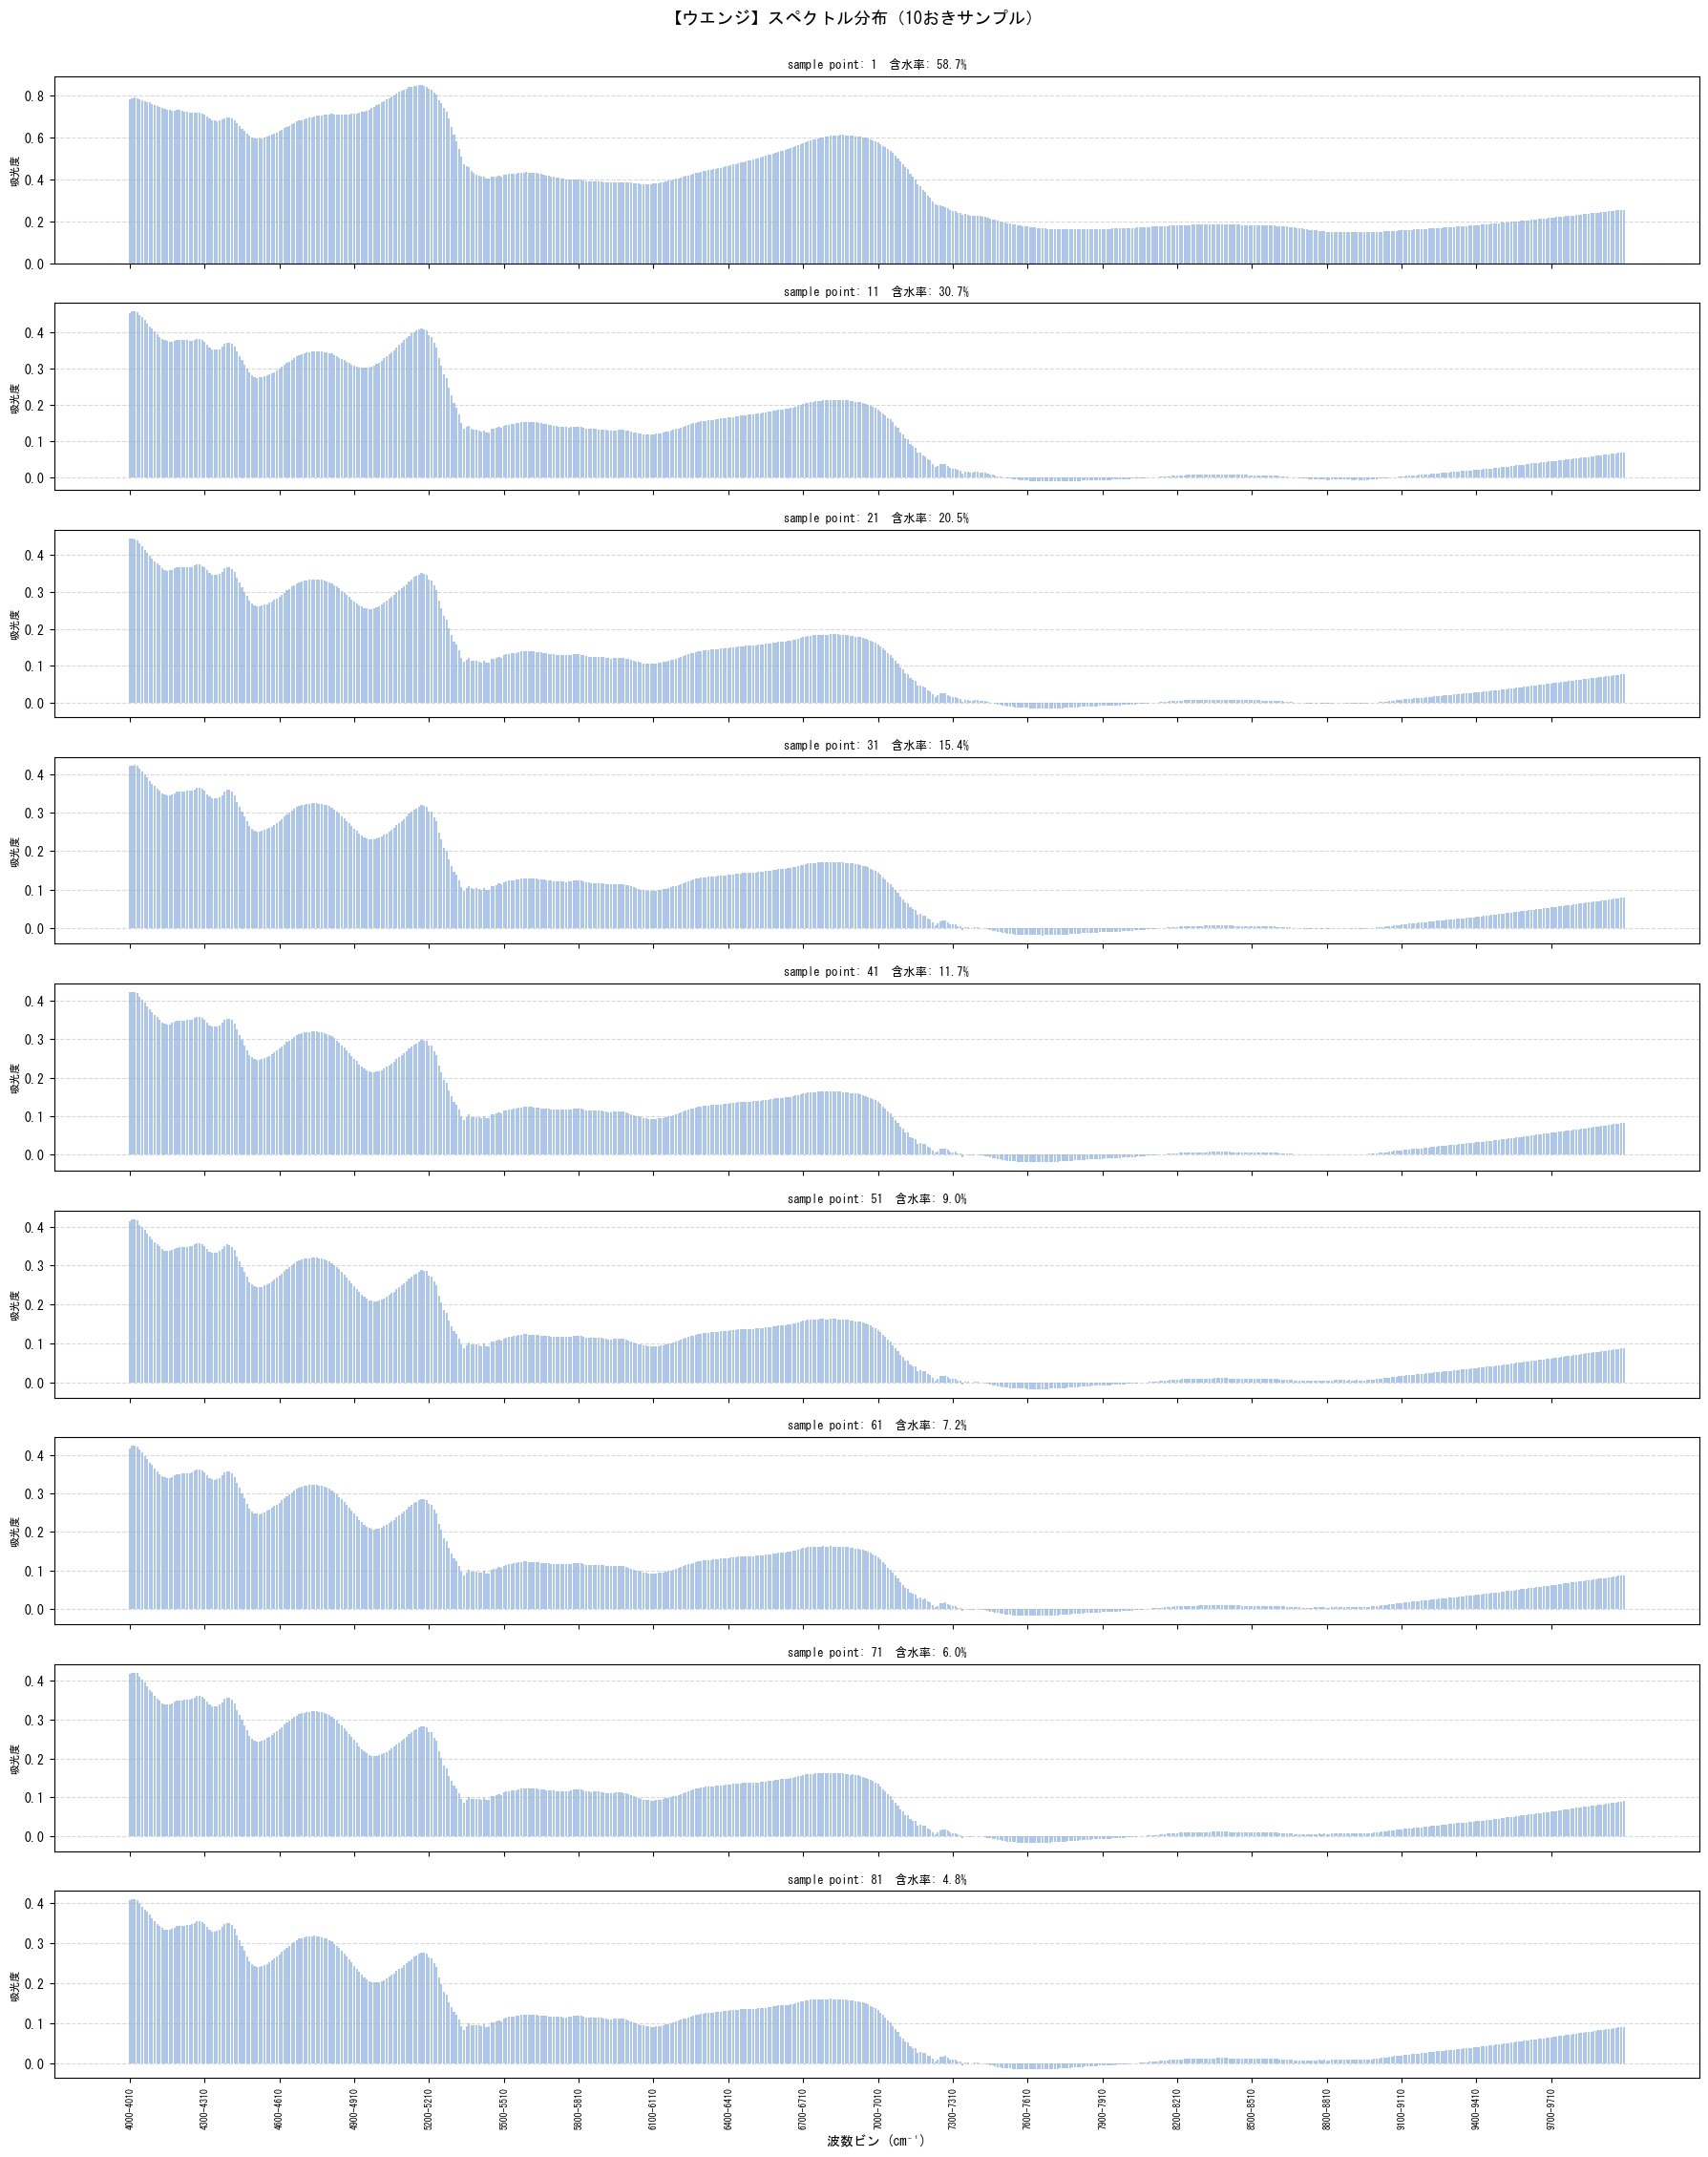

C:\Users\keisu\AppData\Local\Temp\ipykernel_13812\278320660.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  subset['point'] = subset.index + 1


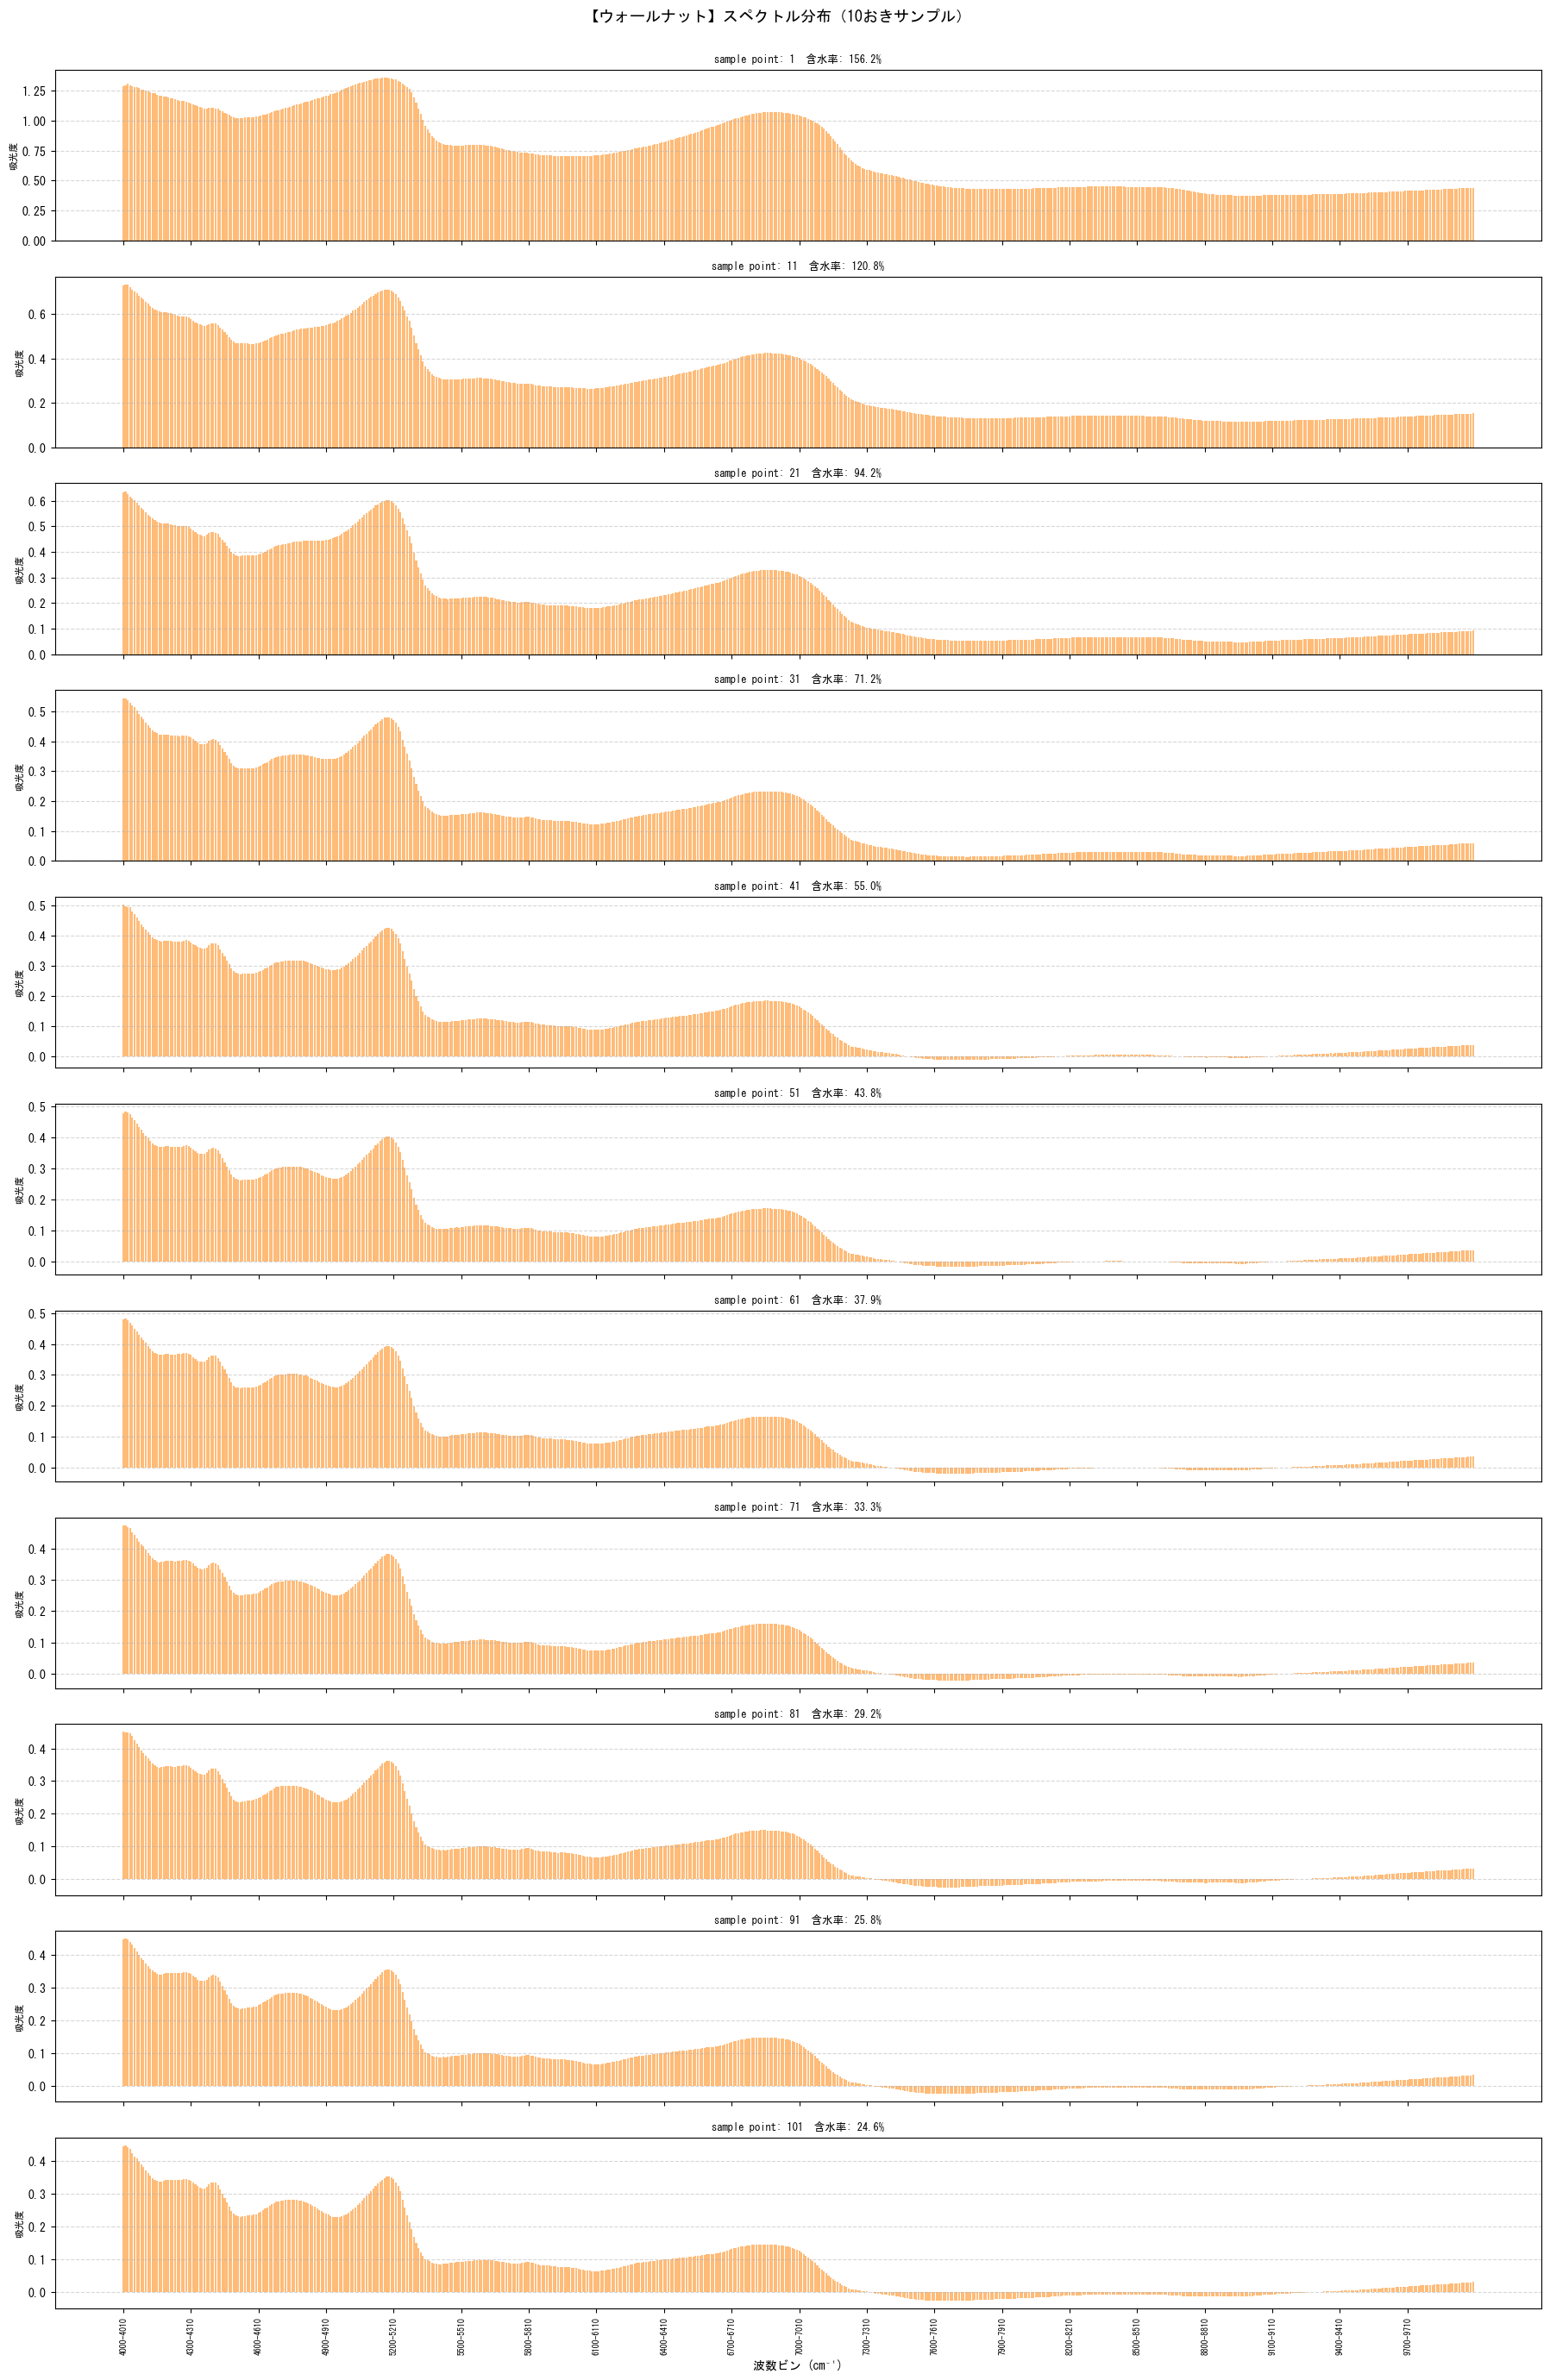

C:\Users\keisu\AppData\Local\Temp\ipykernel_13812\278320660.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  subset['point'] = subset.index + 1


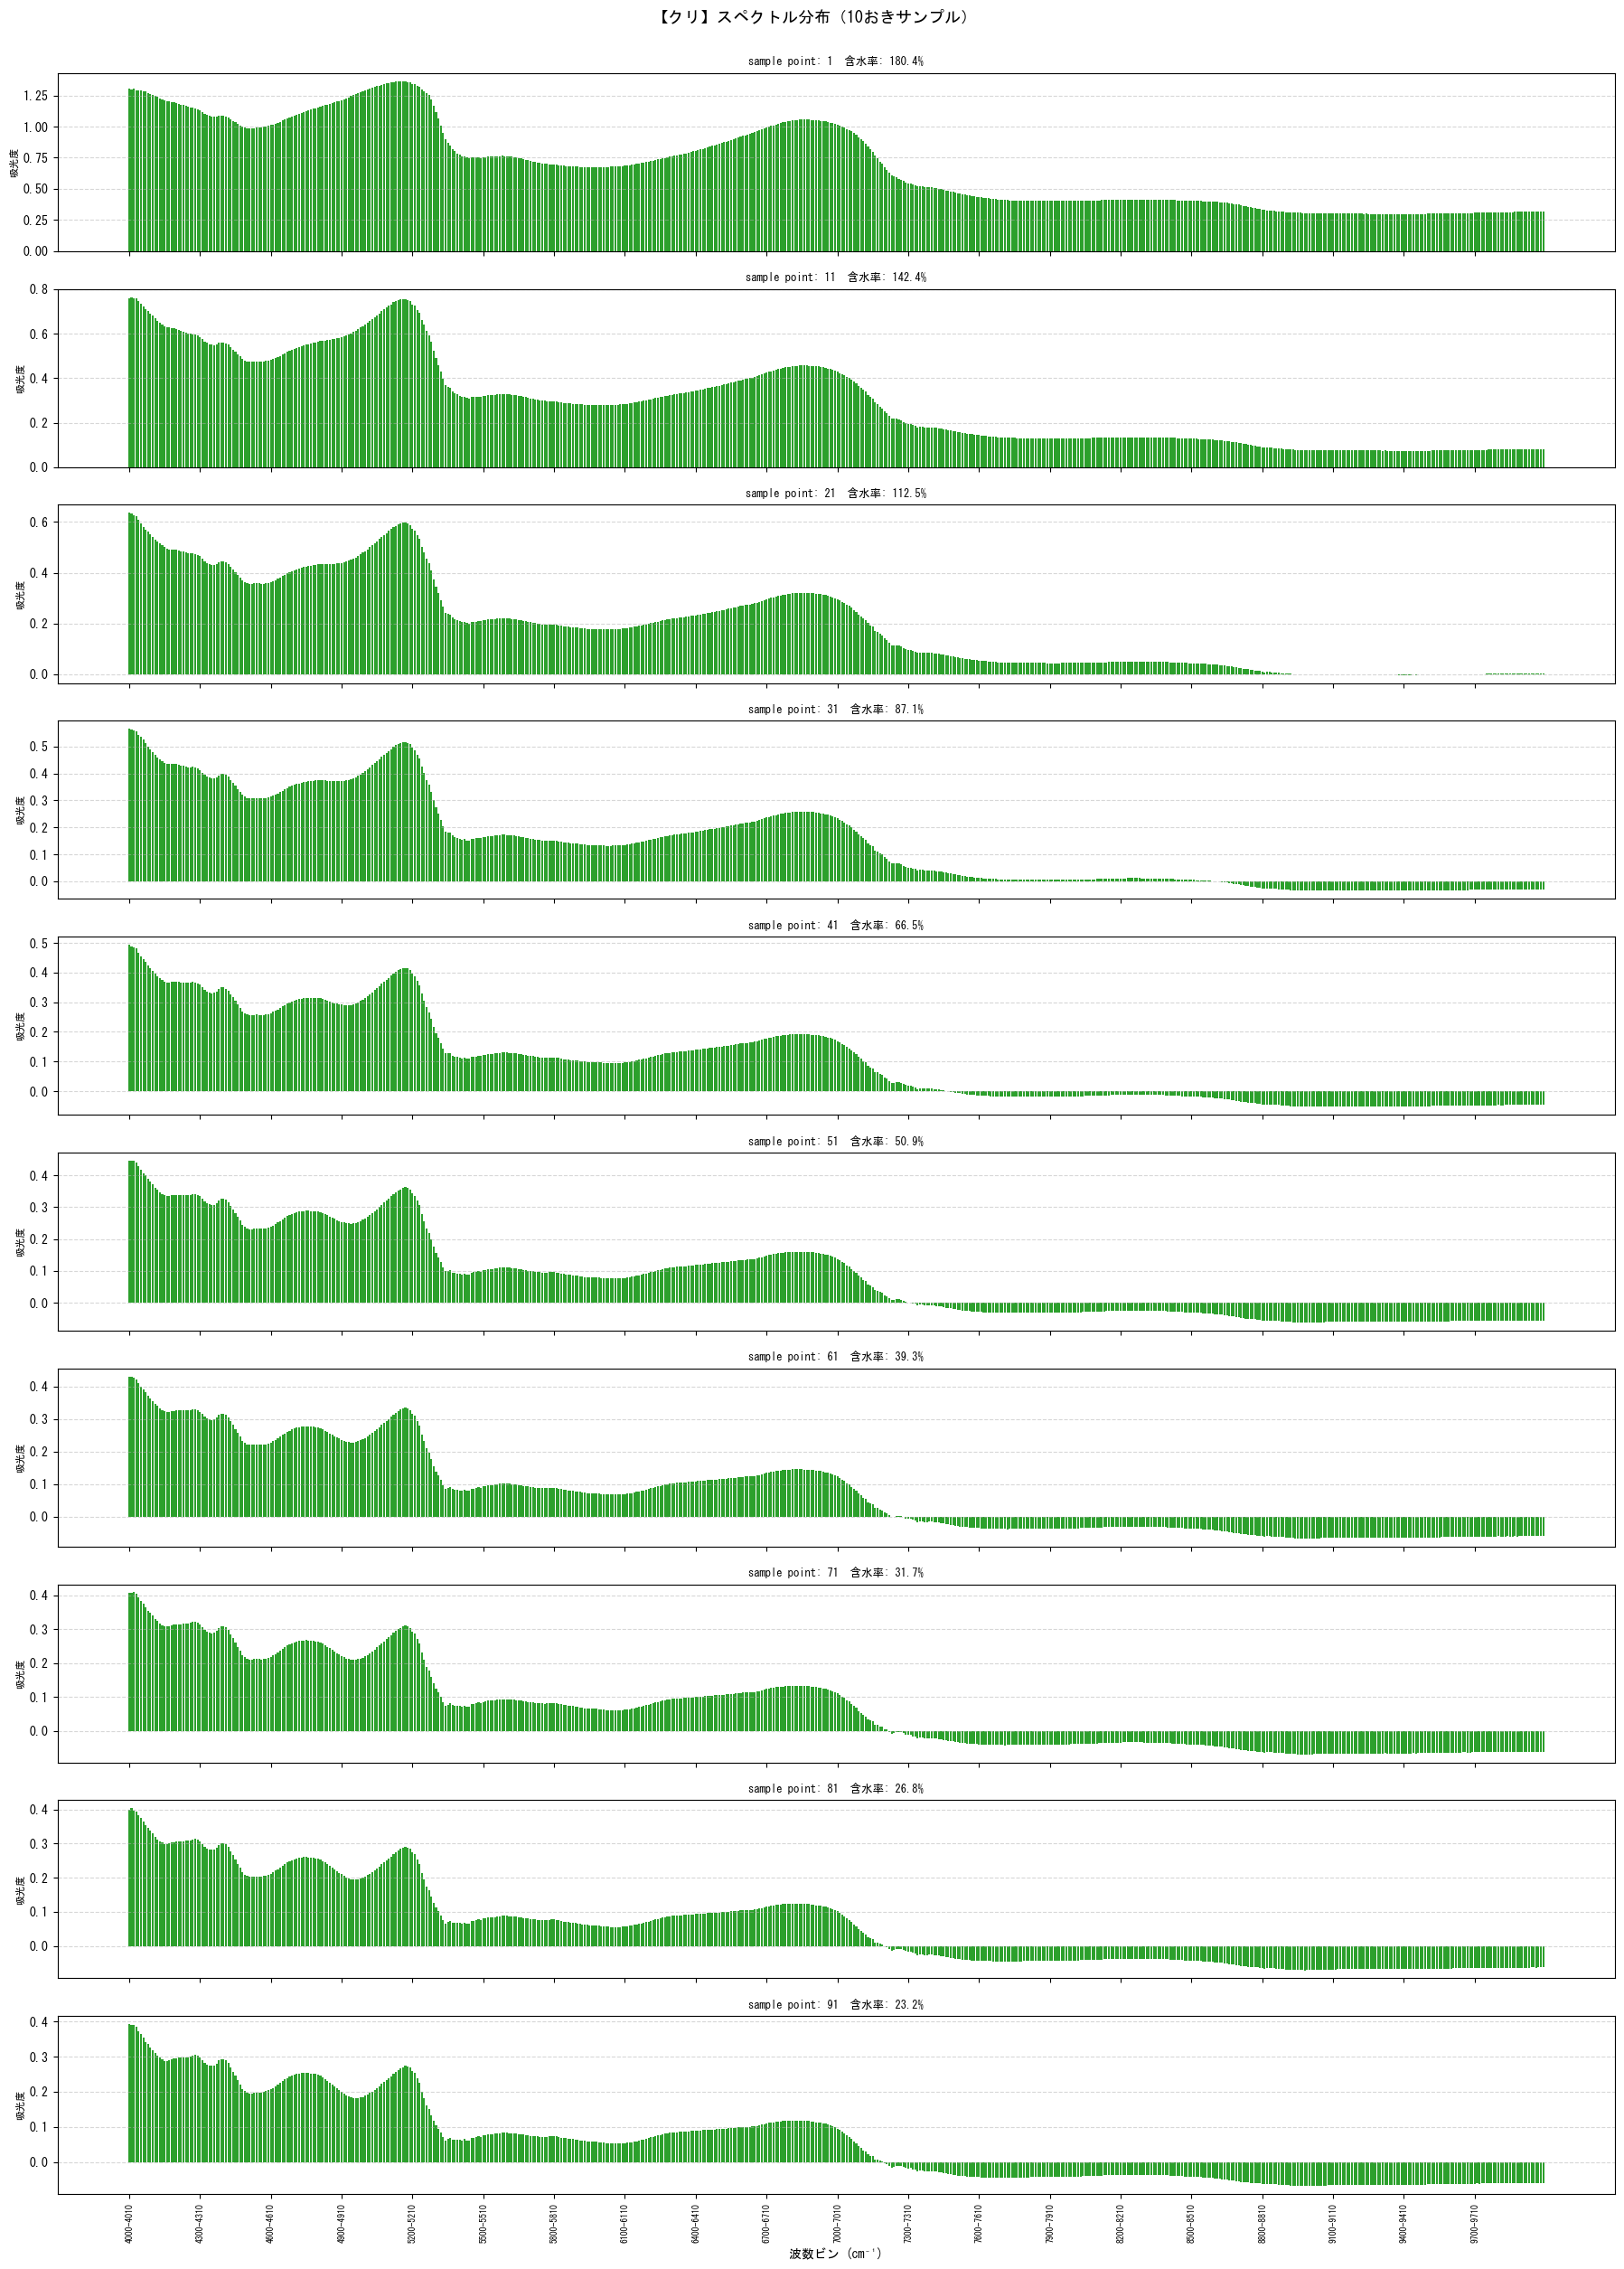

C:\Users\keisu\AppData\Local\Temp\ipykernel_13812\278320660.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  subset['point'] = subset.index + 1


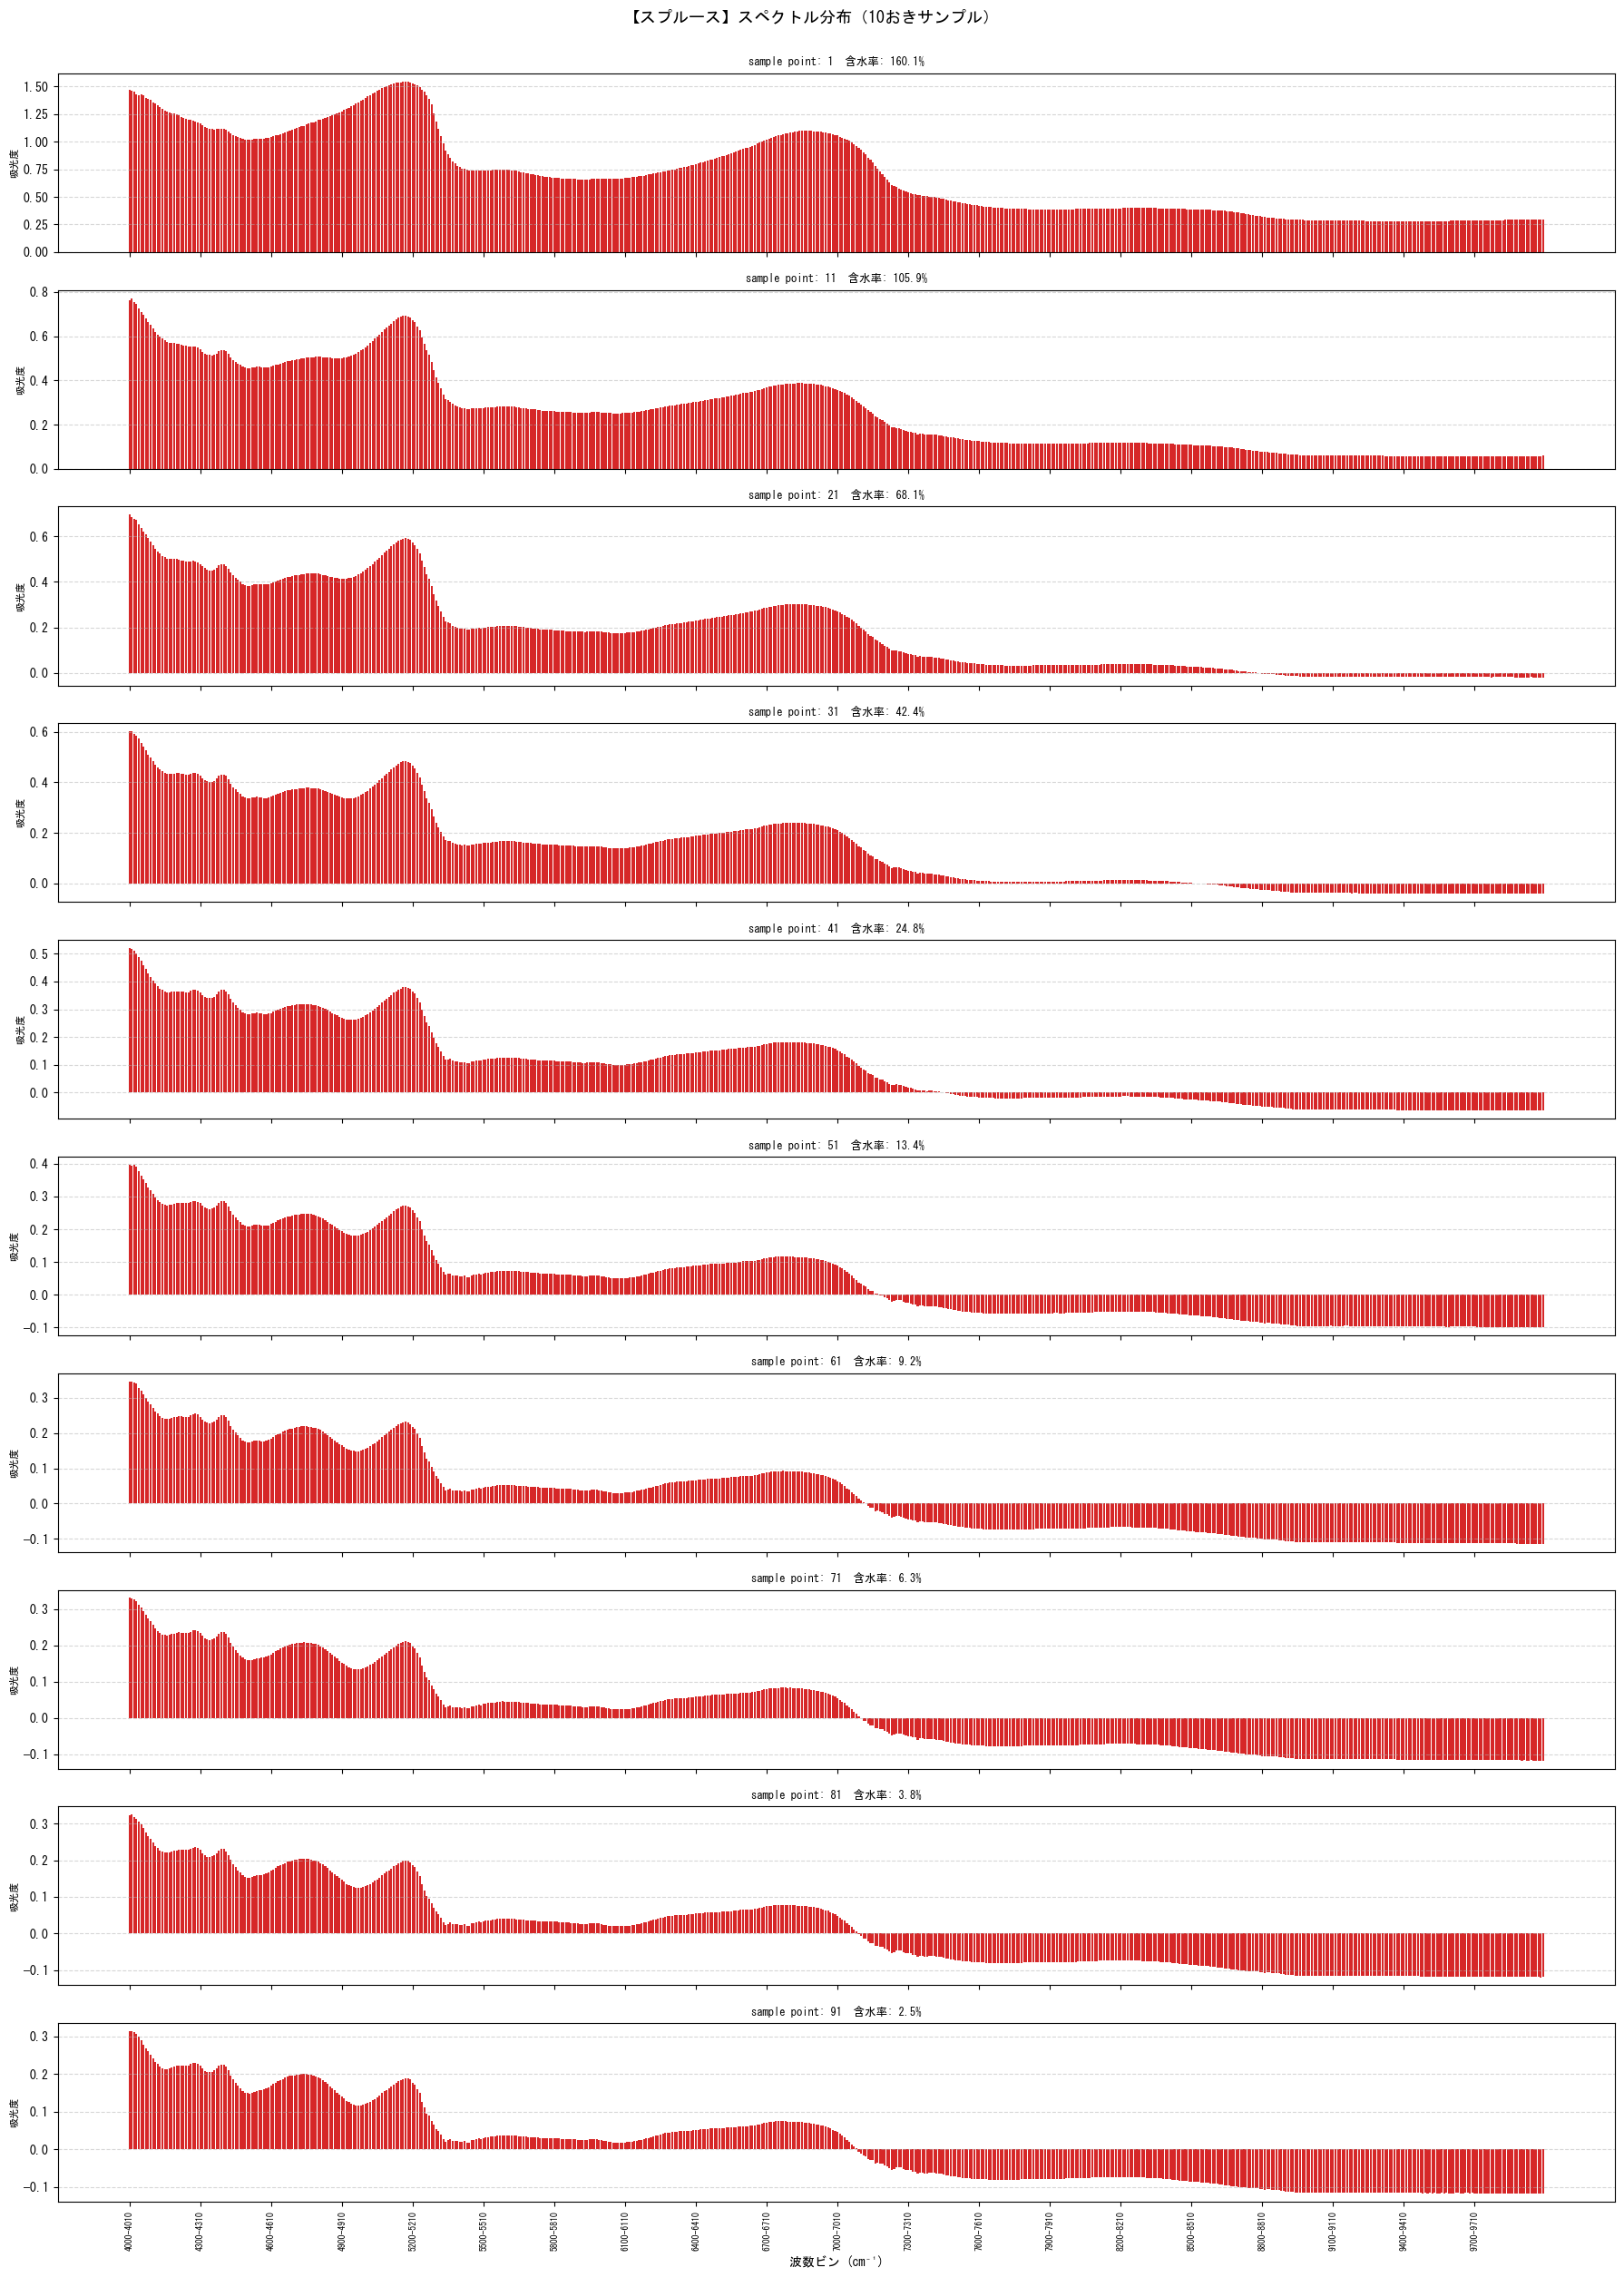

C:\Users\keisu\AppData\Local\Temp\ipykernel_13812\278320660.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  subset['point'] = subset.index + 1


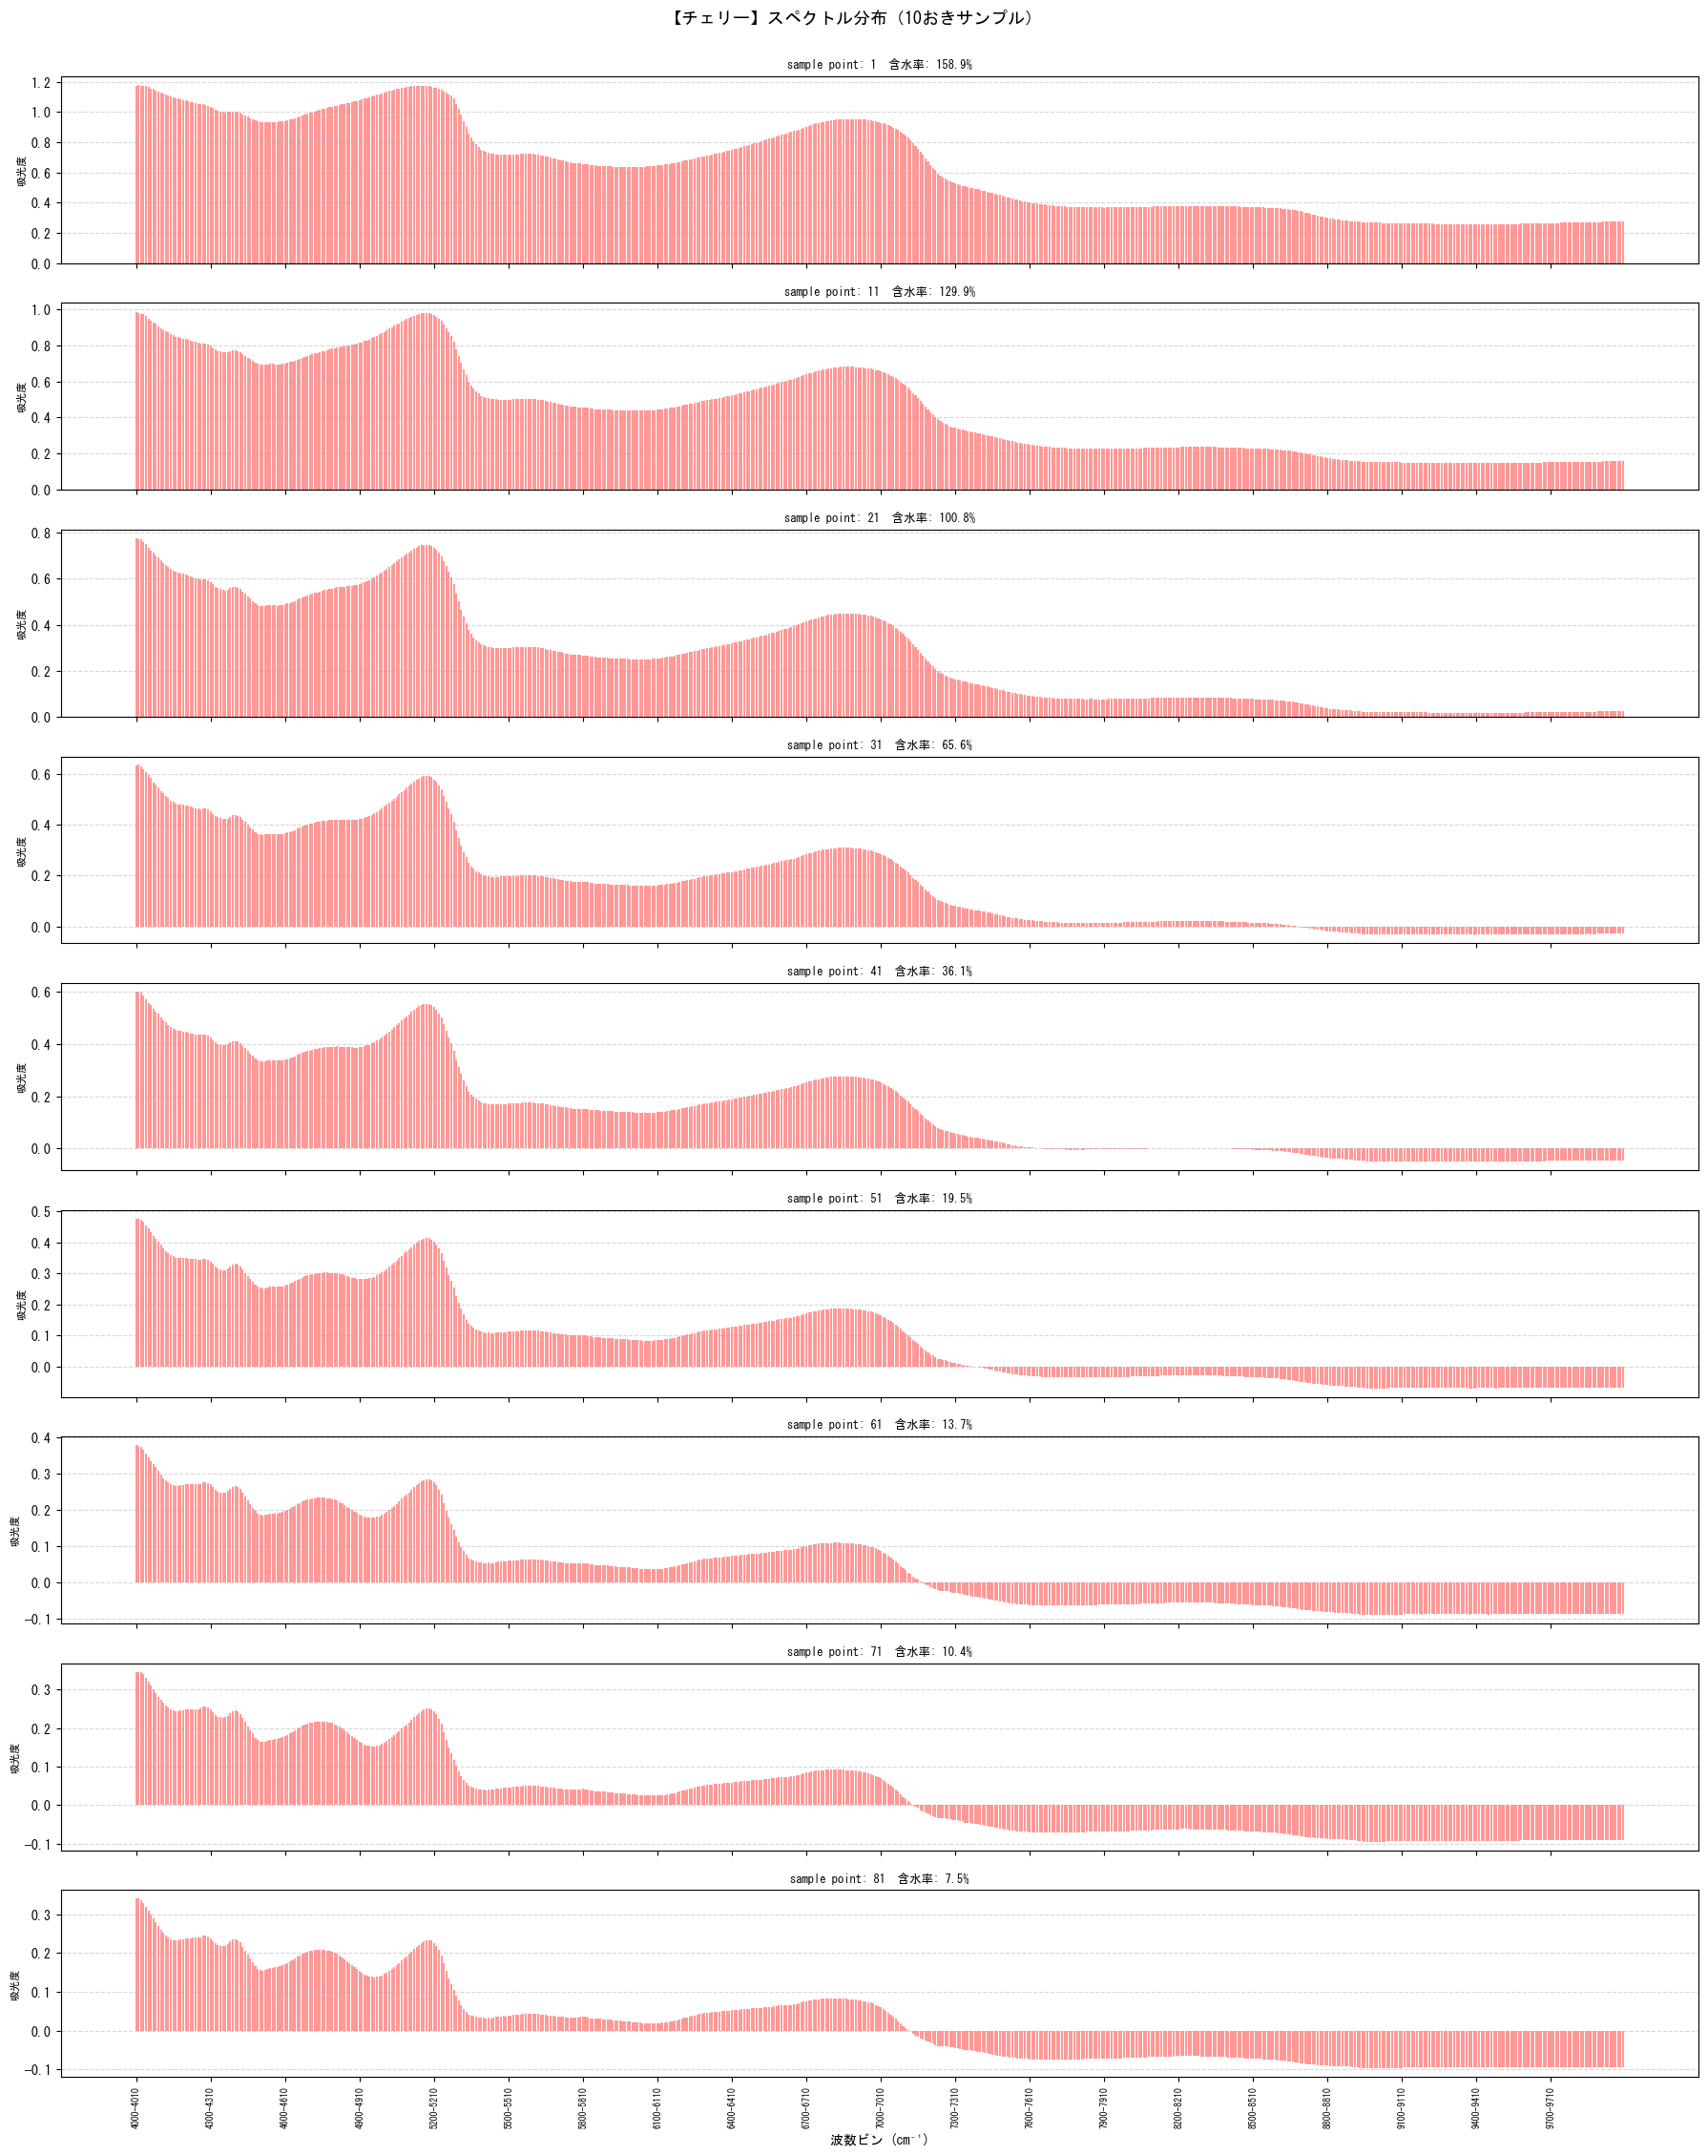

C:\Users\keisu\AppData\Local\Temp\ipykernel_13812\278320660.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  subset['point'] = subset.index + 1


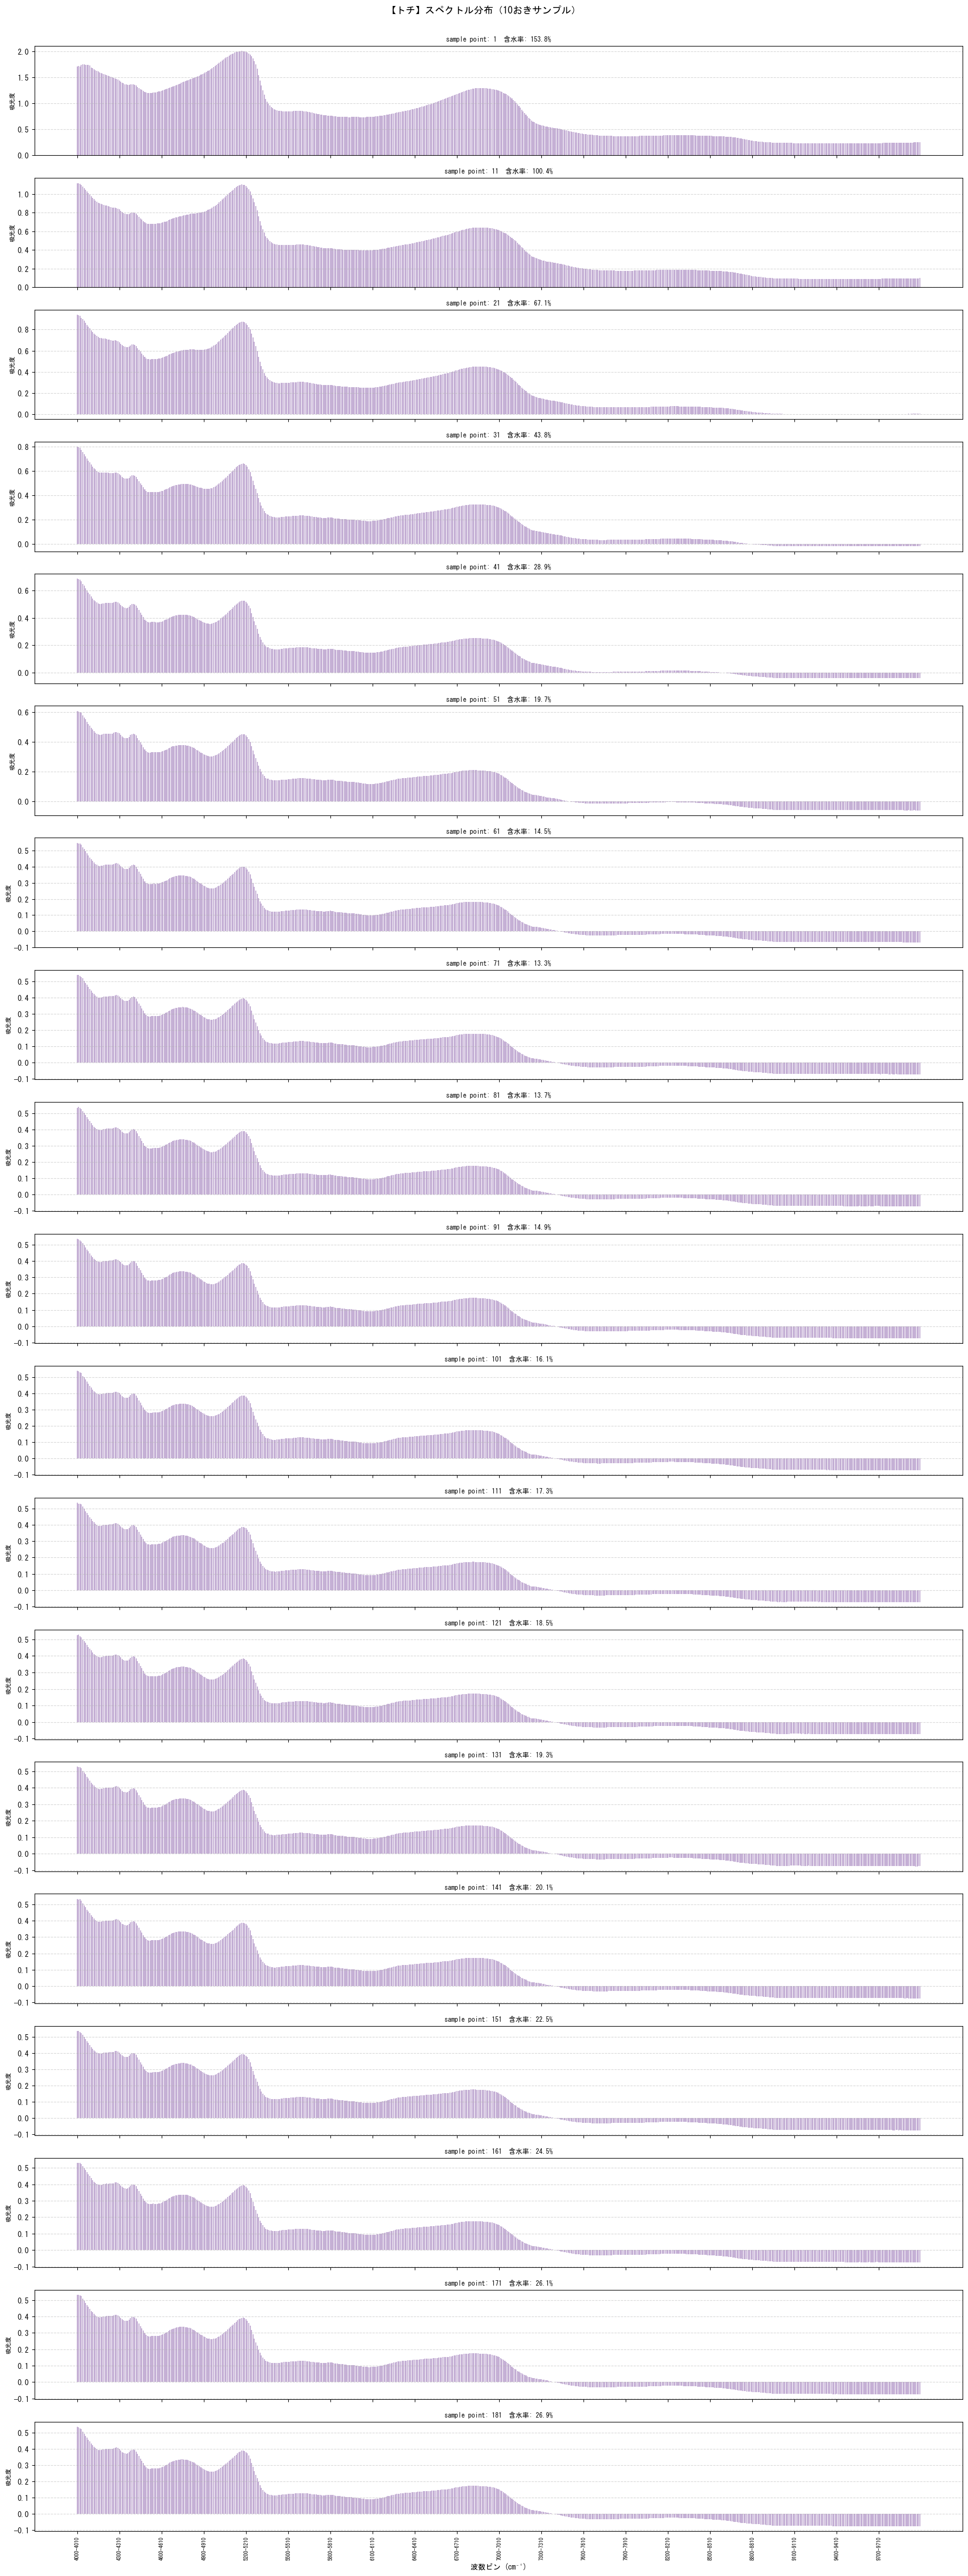

C:\Users\keisu\AppData\Local\Temp\ipykernel_13812\278320660.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  subset['point'] = subset.index + 1


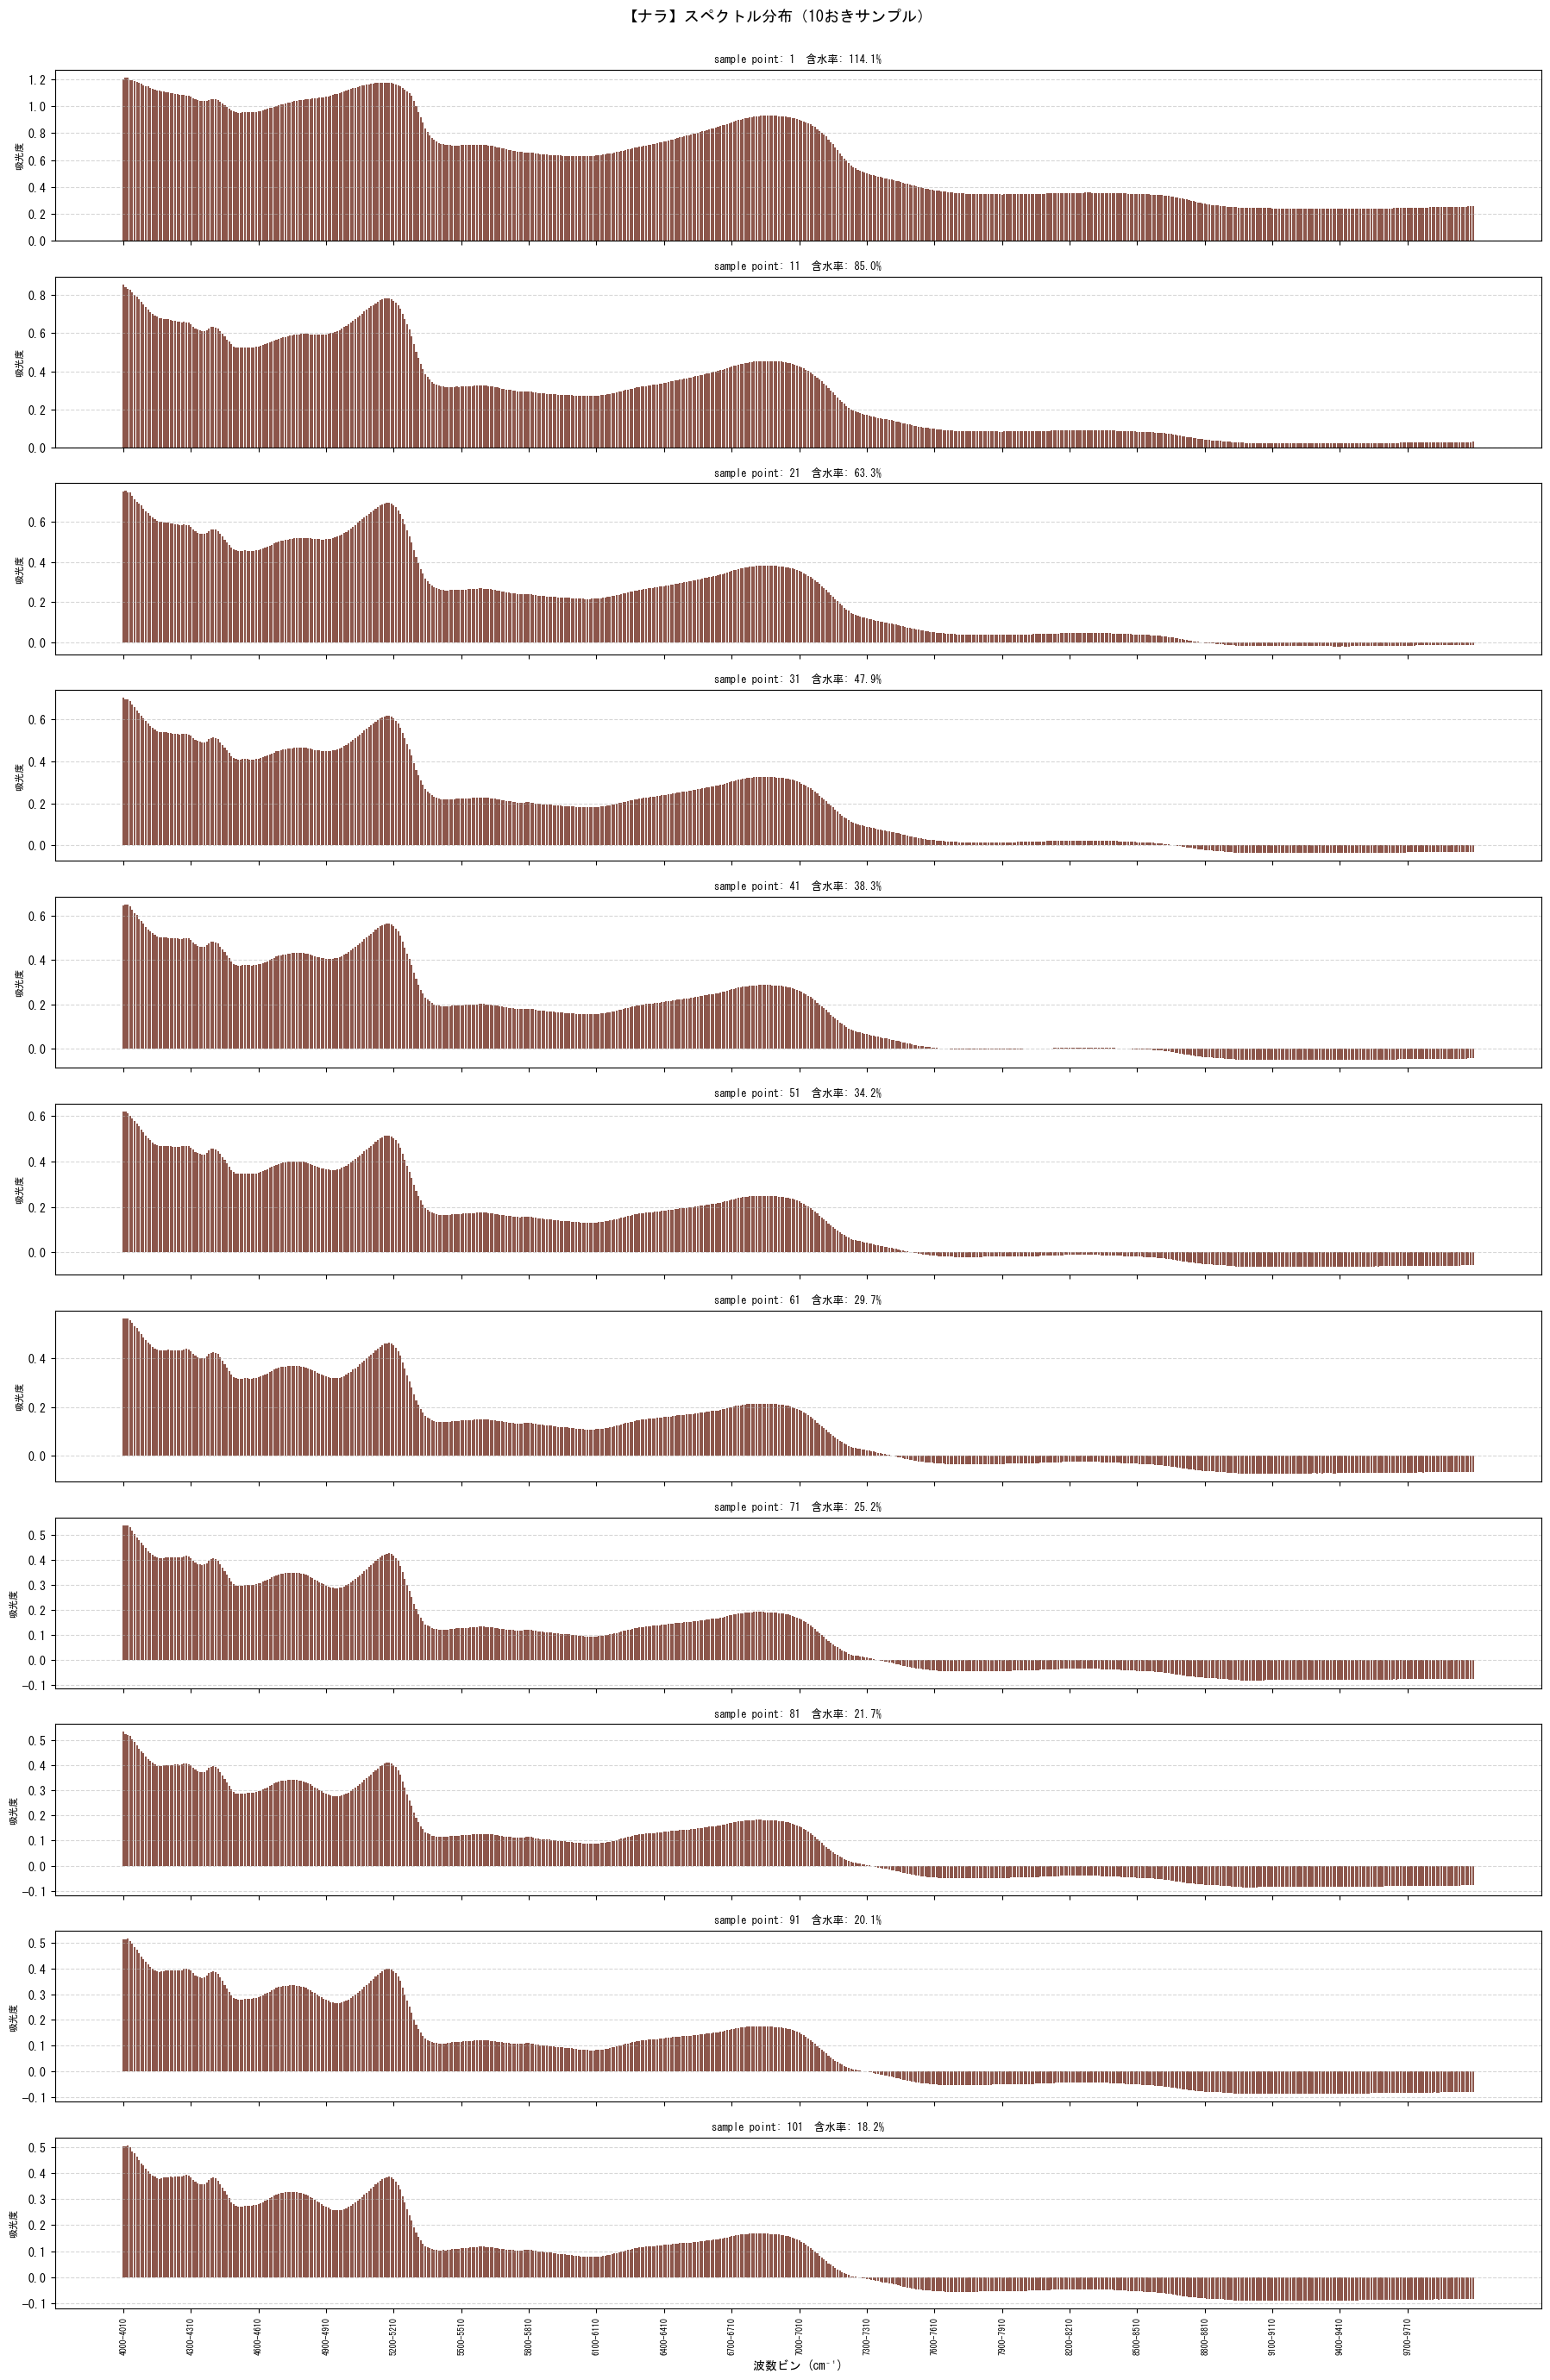

C:\Users\keisu\AppData\Local\Temp\ipykernel_13812\278320660.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  subset['point'] = subset.index + 1


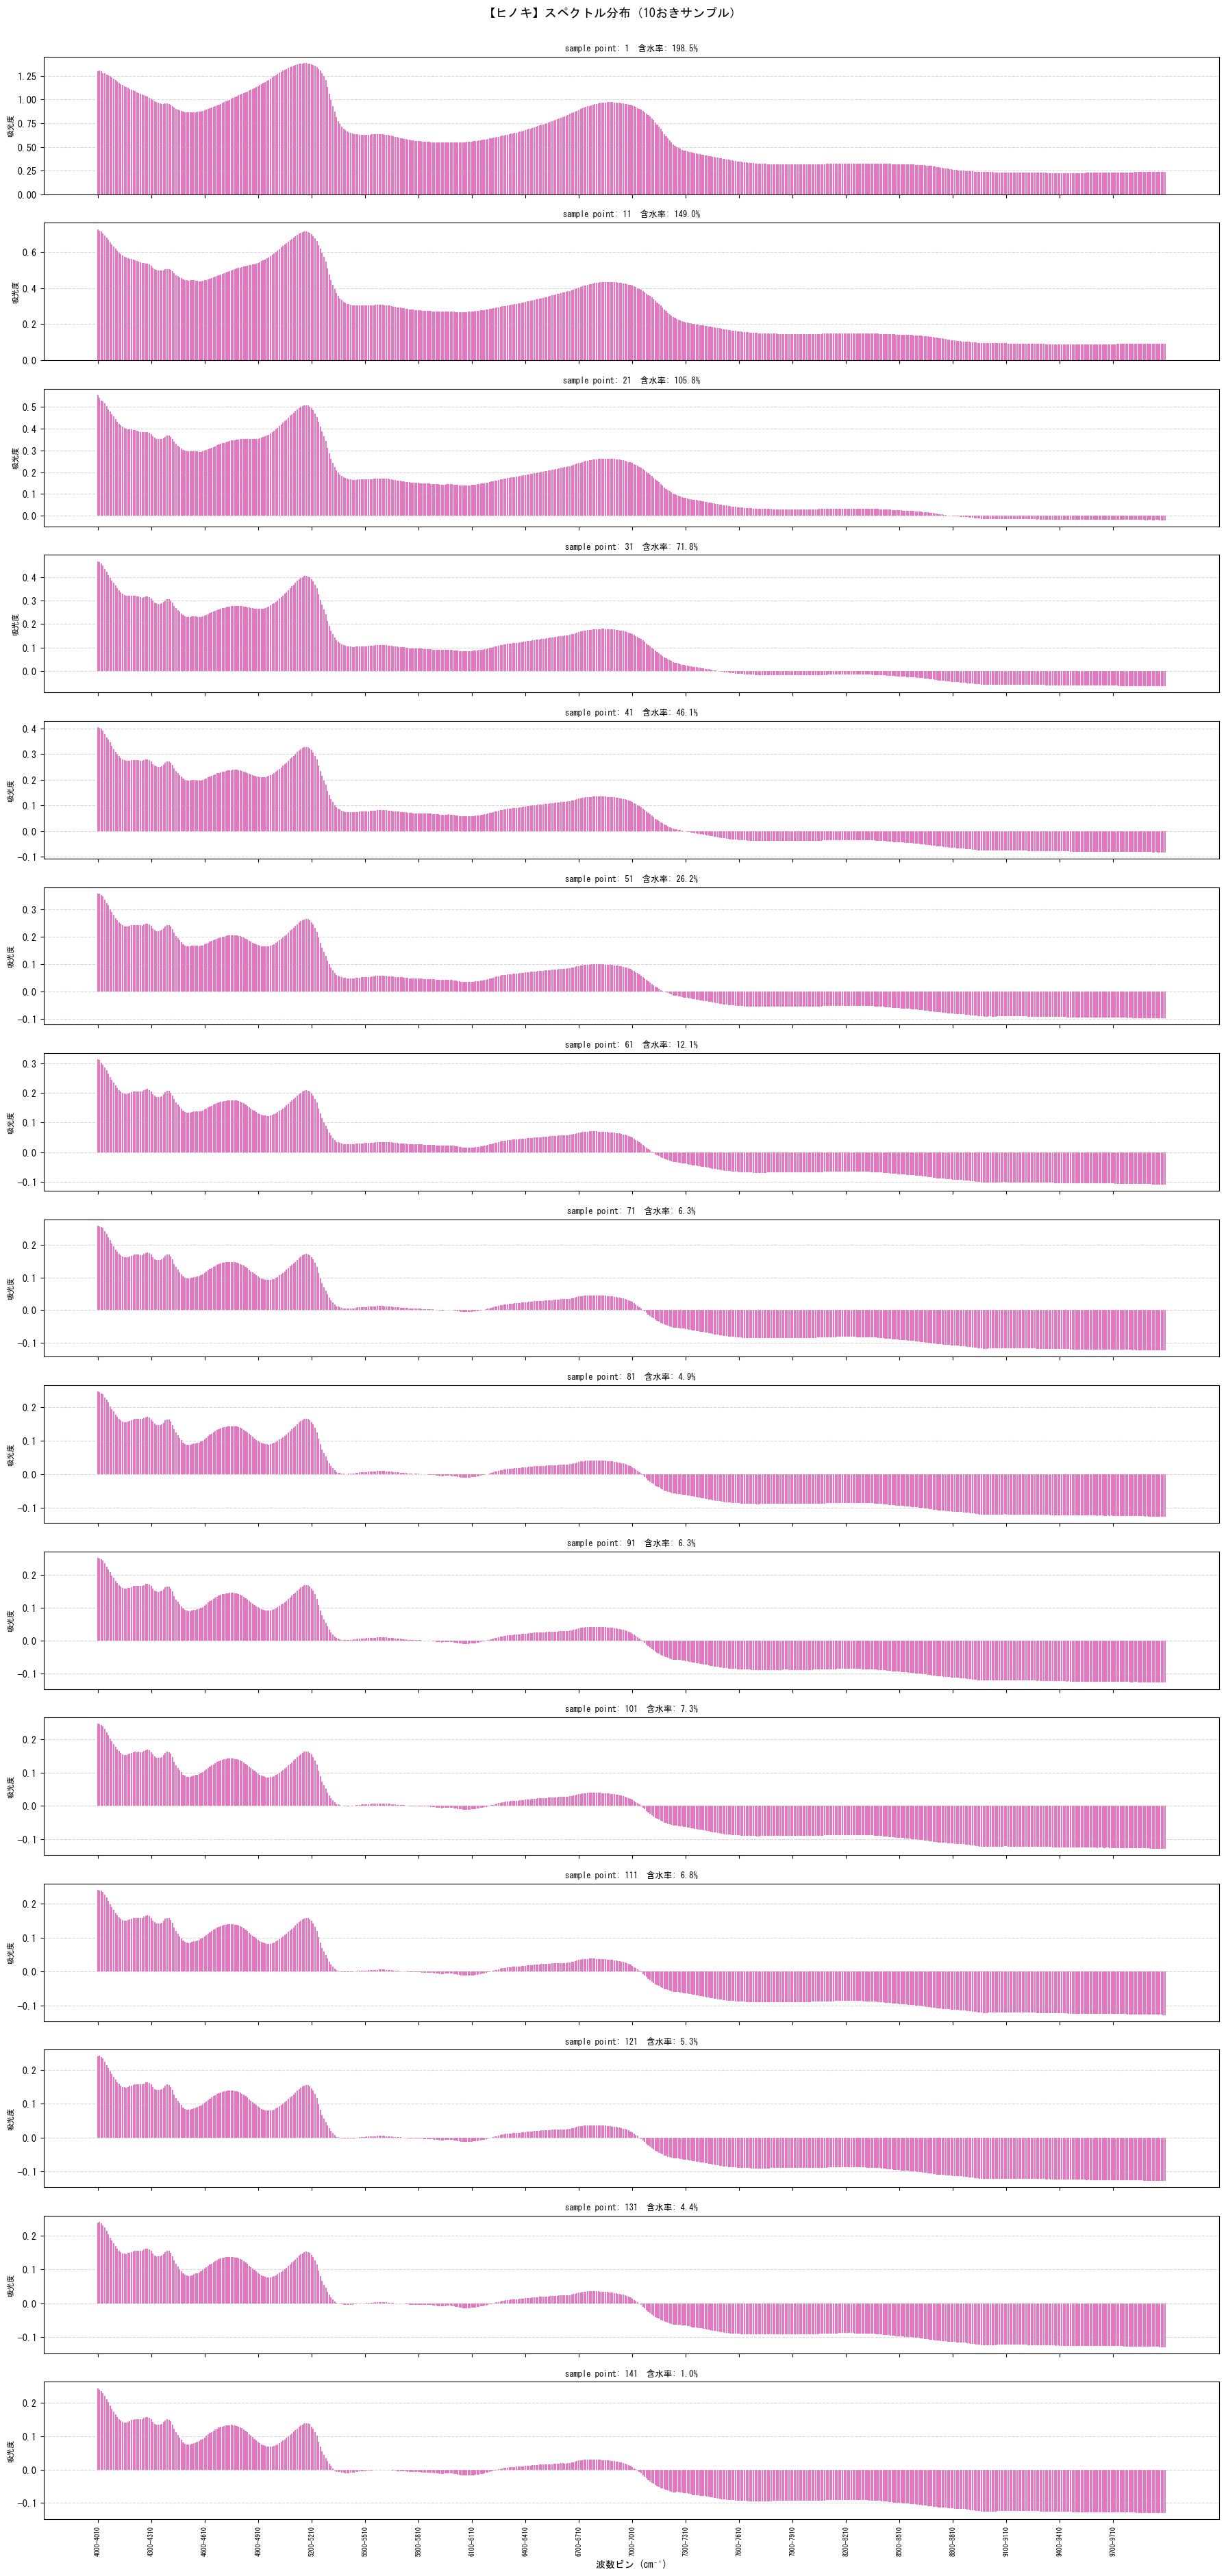

C:\Users\keisu\AppData\Local\Temp\ipykernel_13812\278320660.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  subset['point'] = subset.index + 1


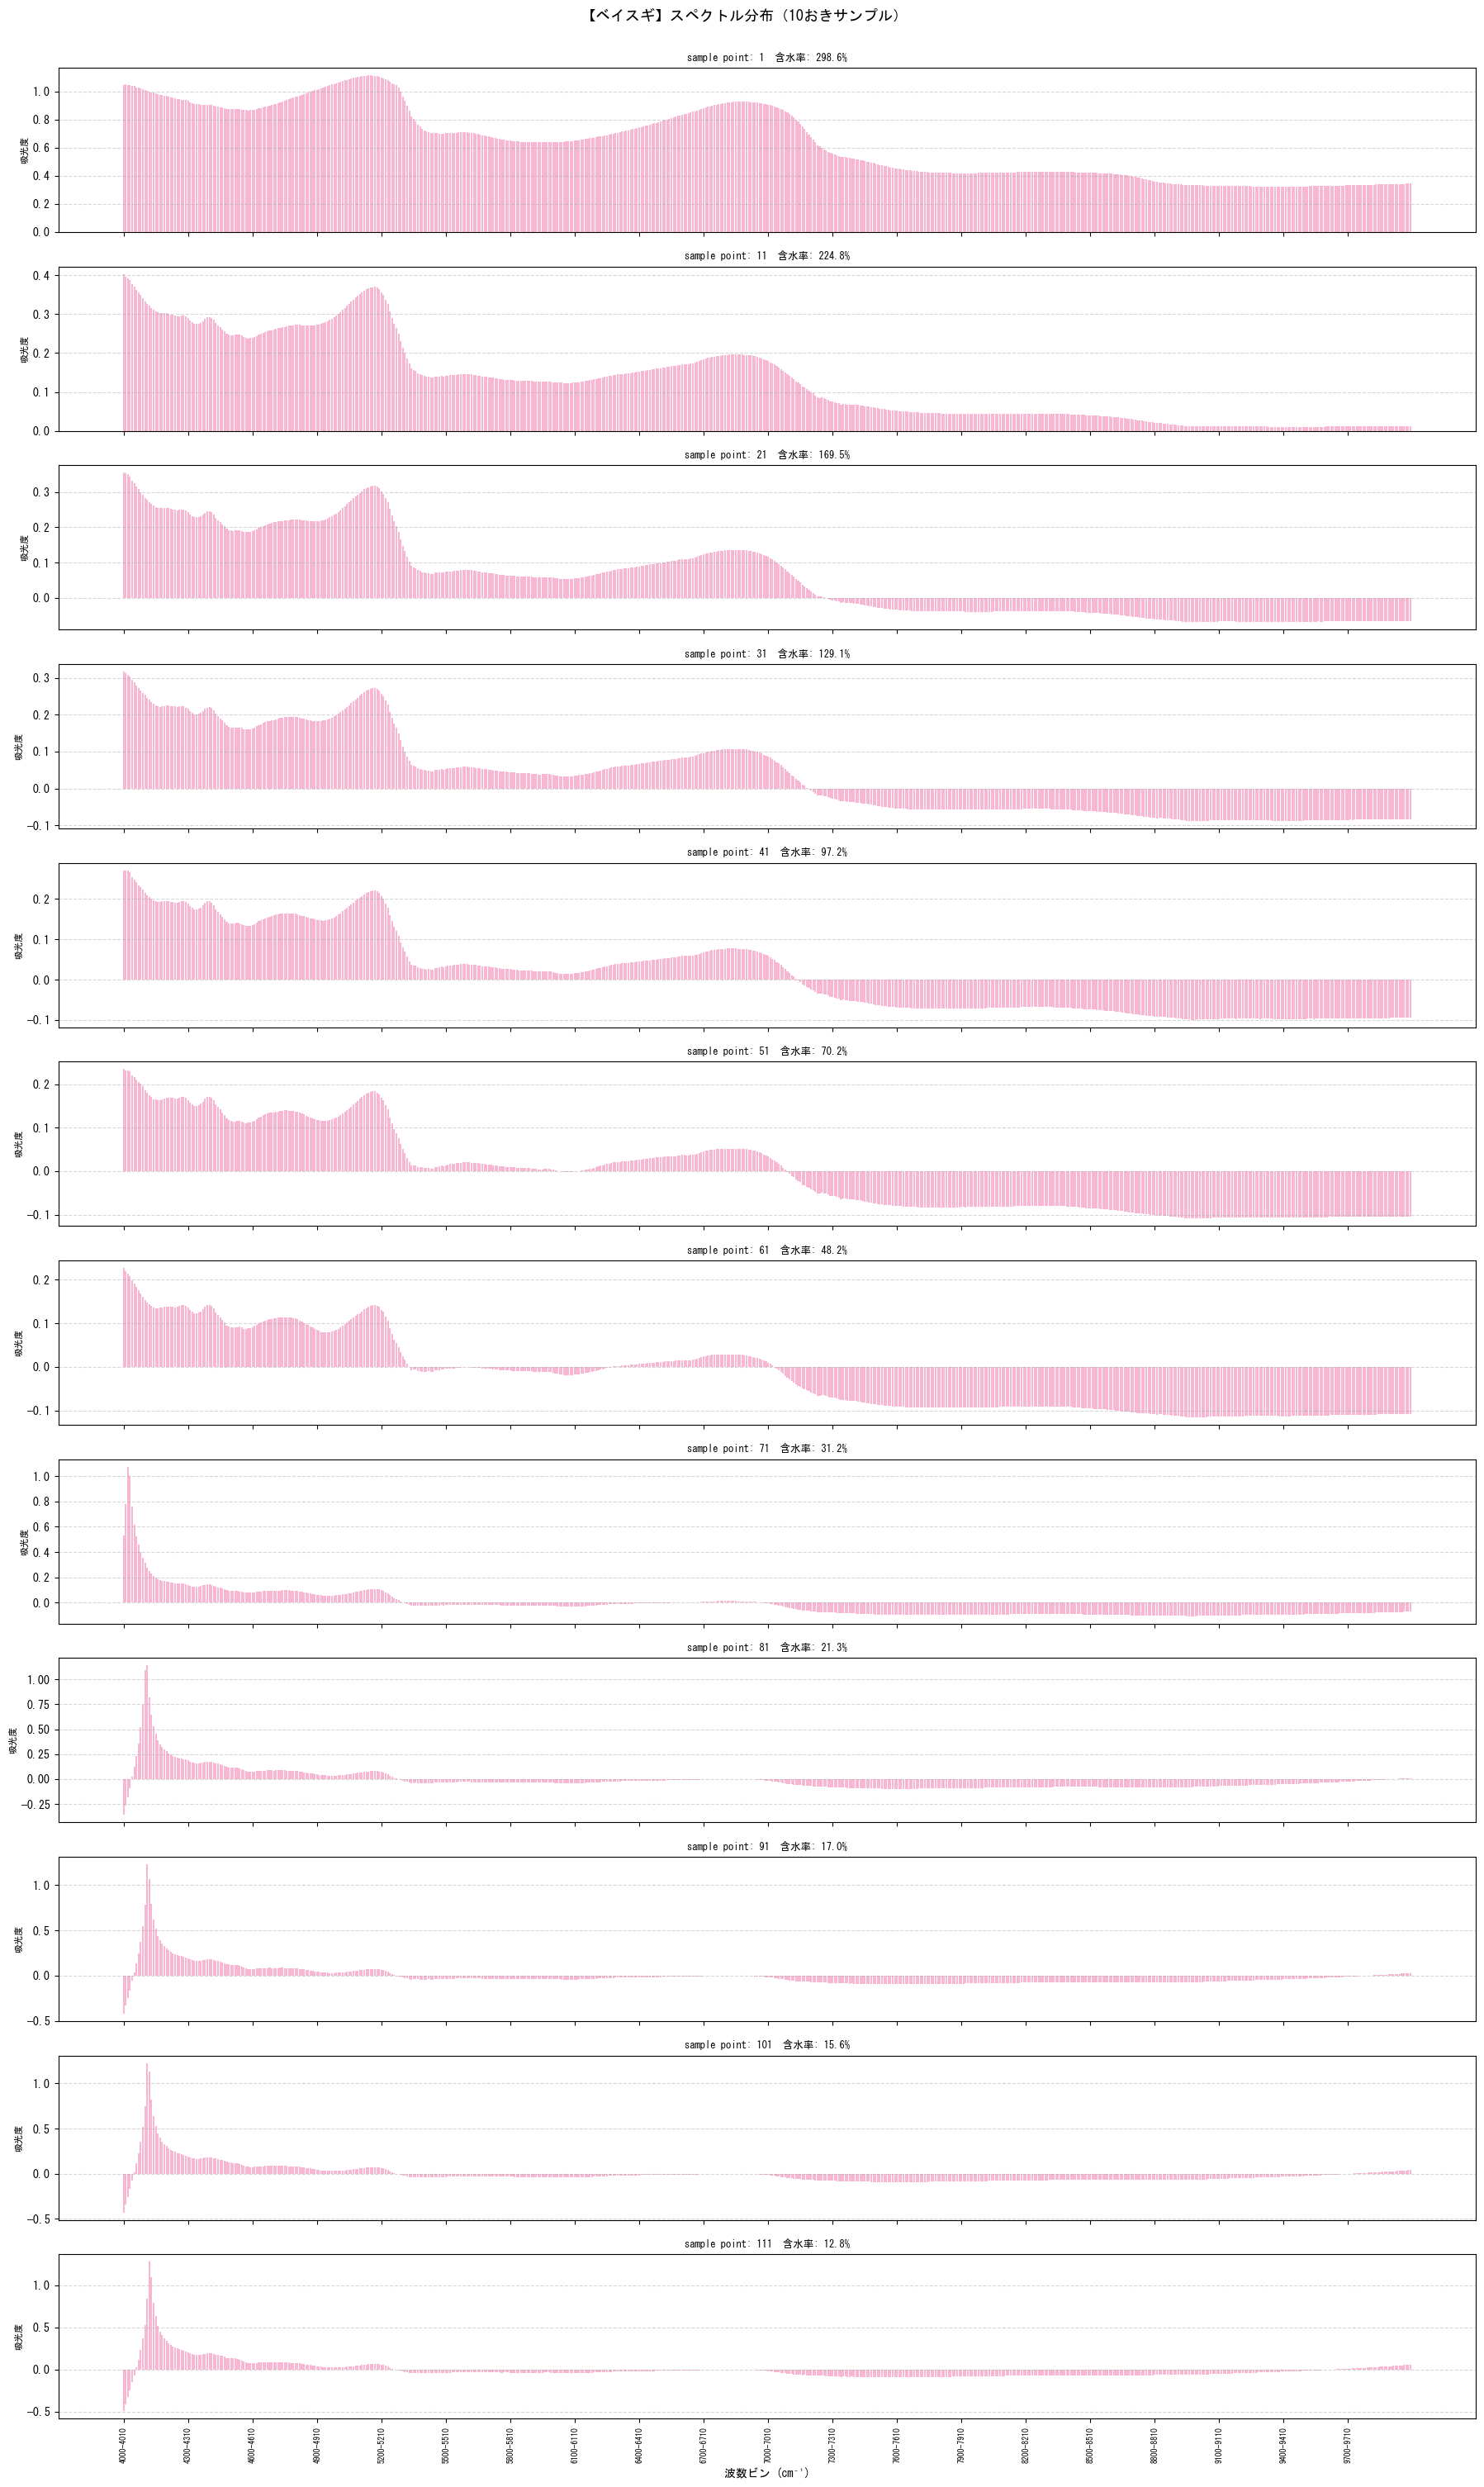

C:\Users\keisu\AppData\Local\Temp\ipykernel_13812\278320660.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  subset['point'] = subset.index + 1


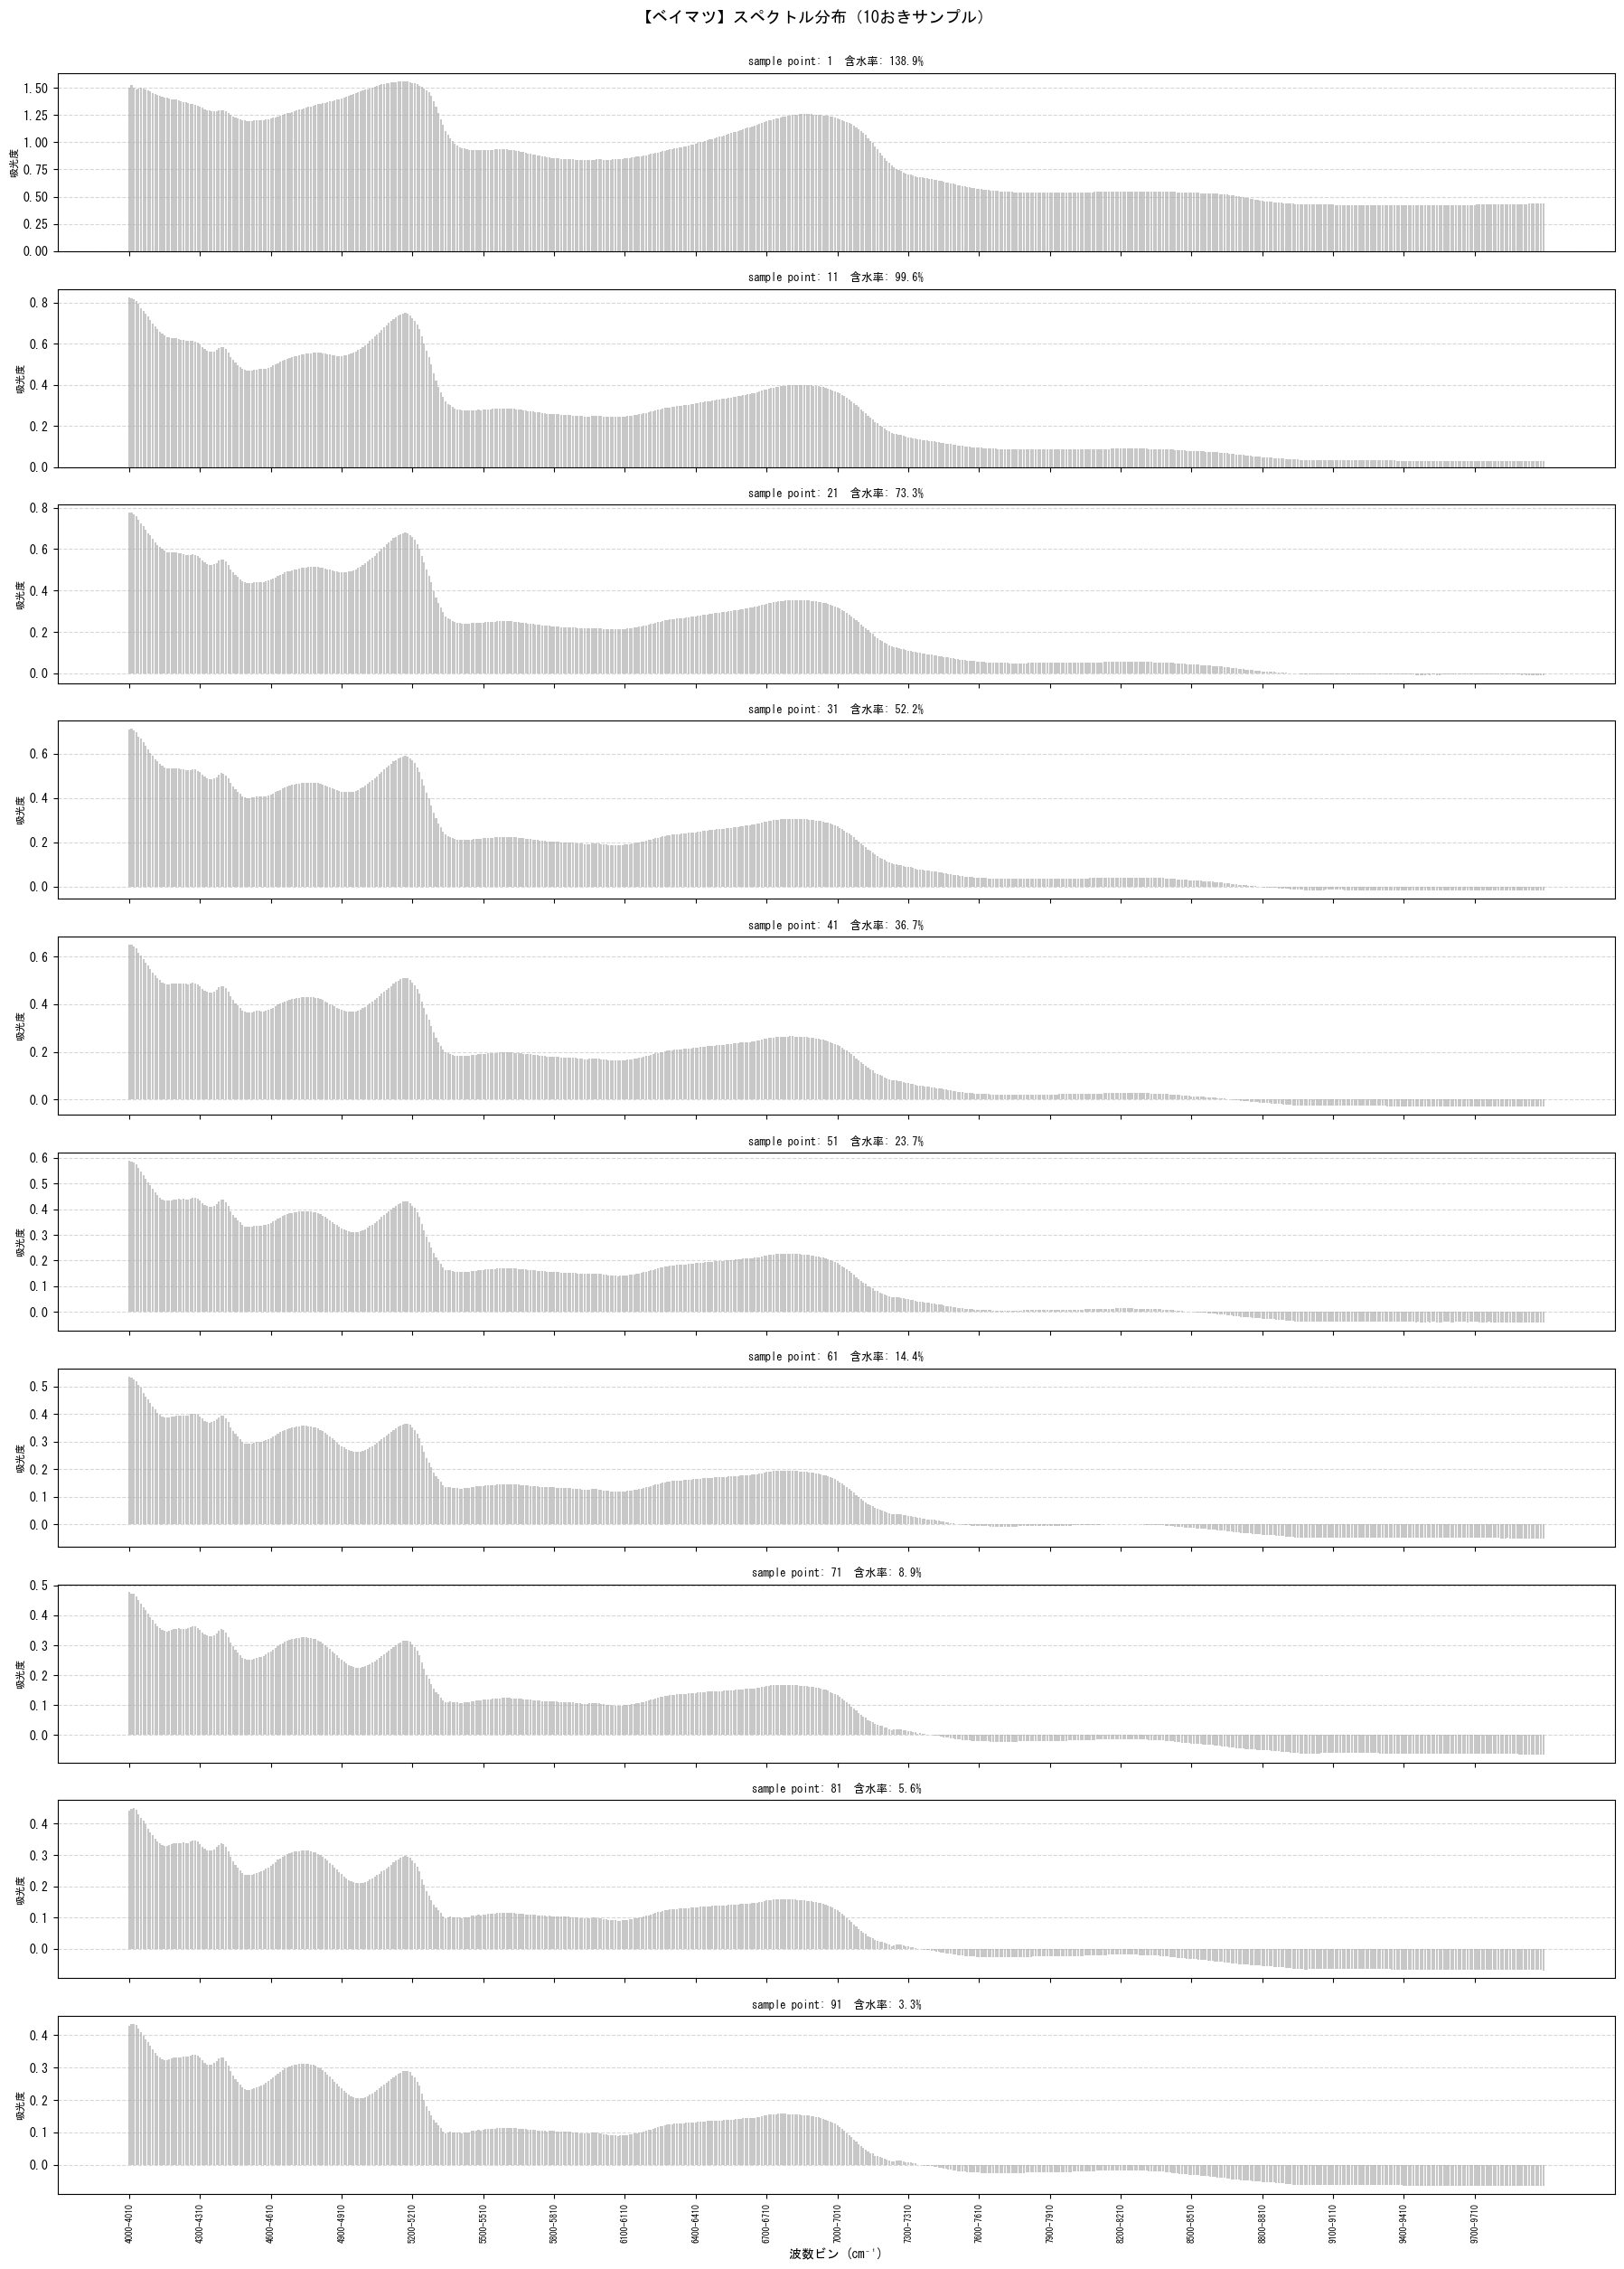

C:\Users\keisu\AppData\Local\Temp\ipykernel_13812\278320660.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  subset['point'] = subset.index + 1


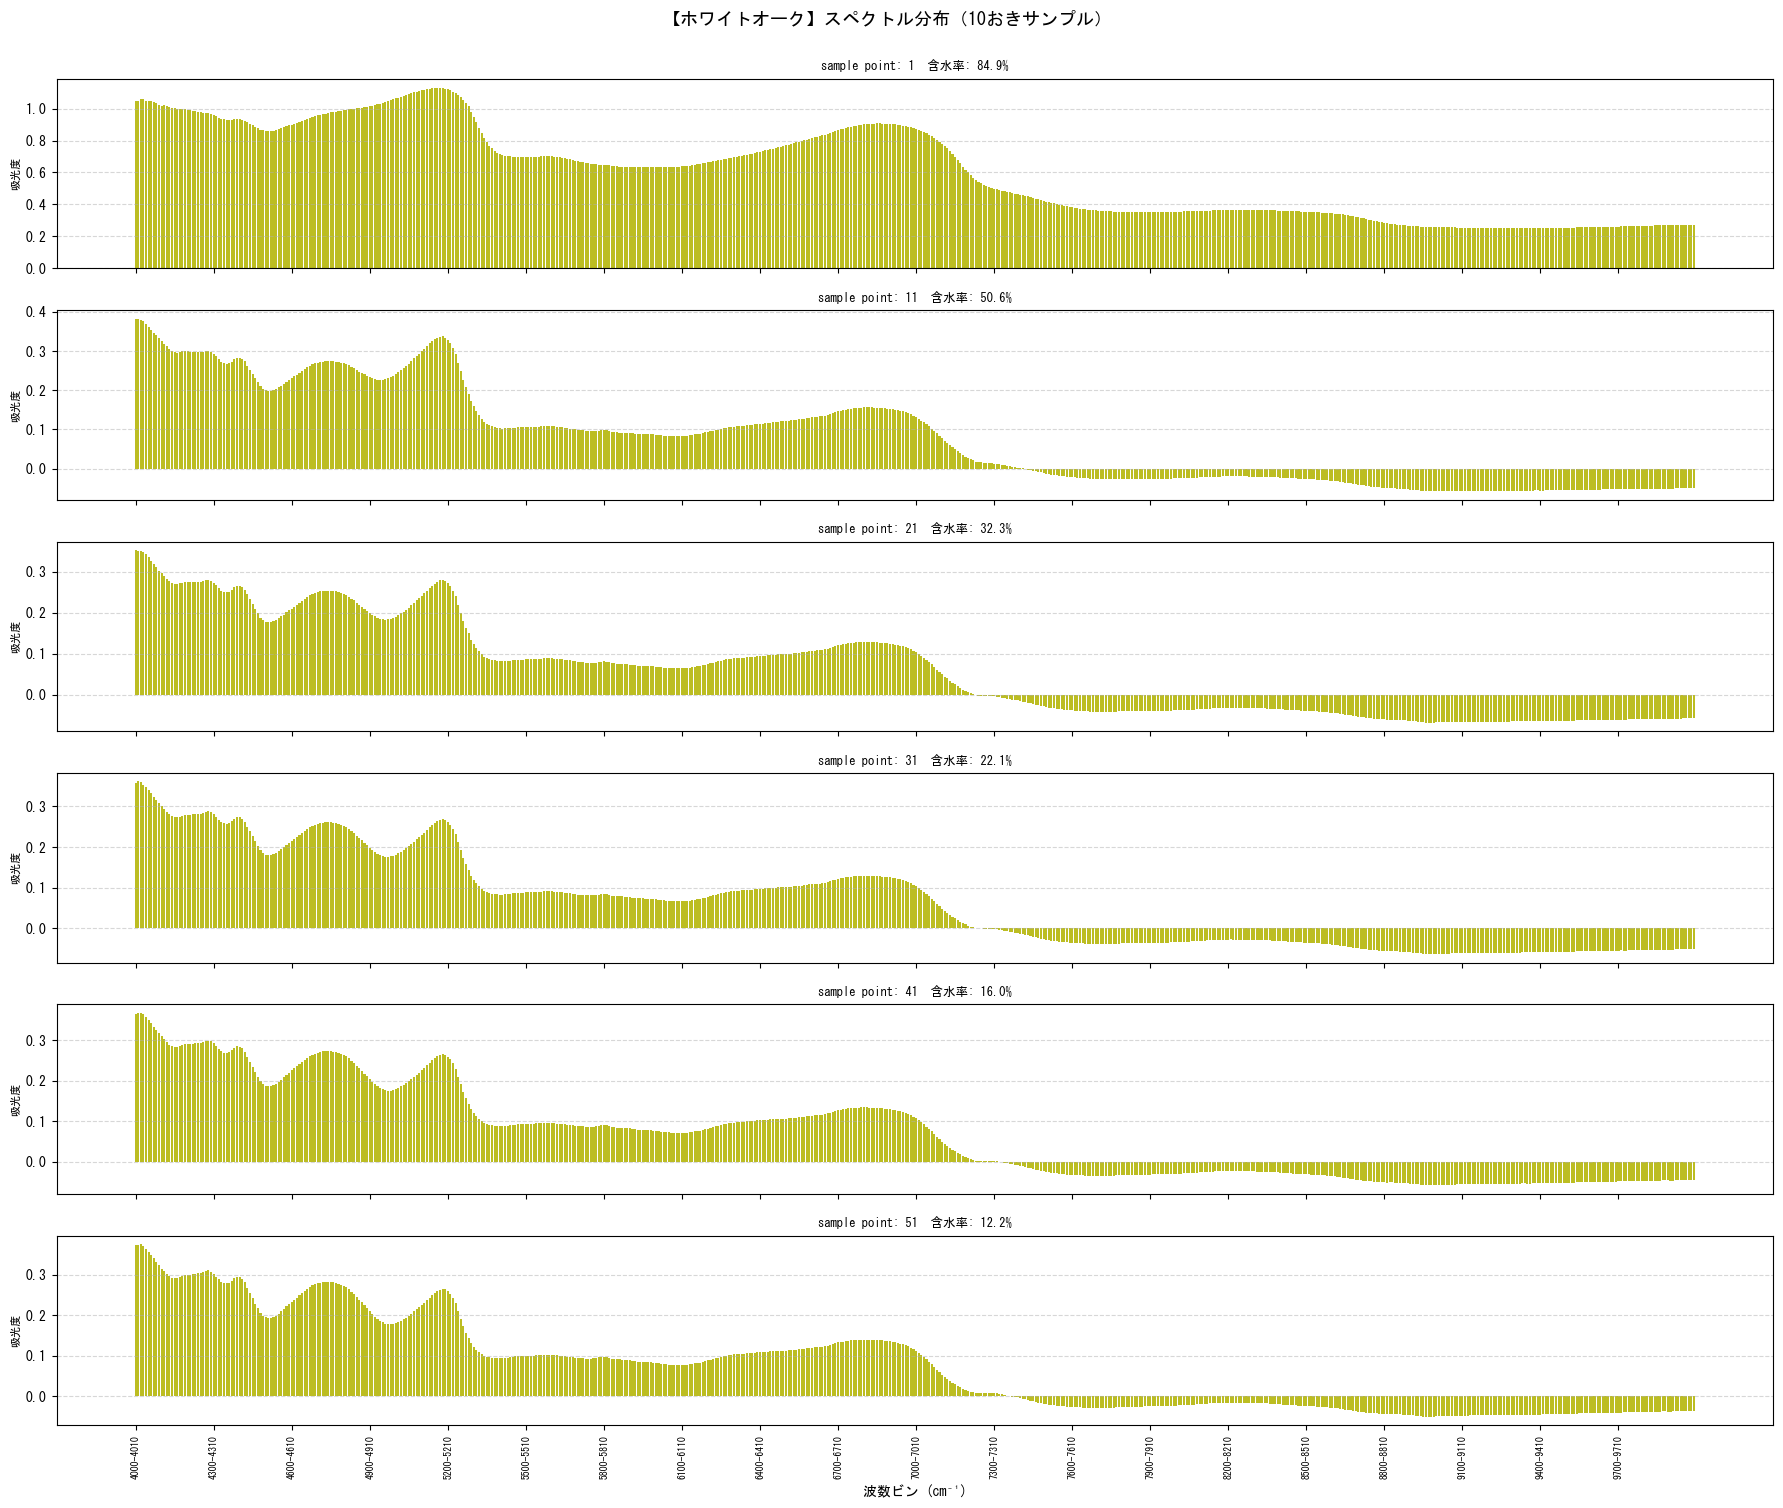

C:\Users\keisu\AppData\Local\Temp\ipykernel_13812\278320660.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  subset['point'] = subset.index + 1


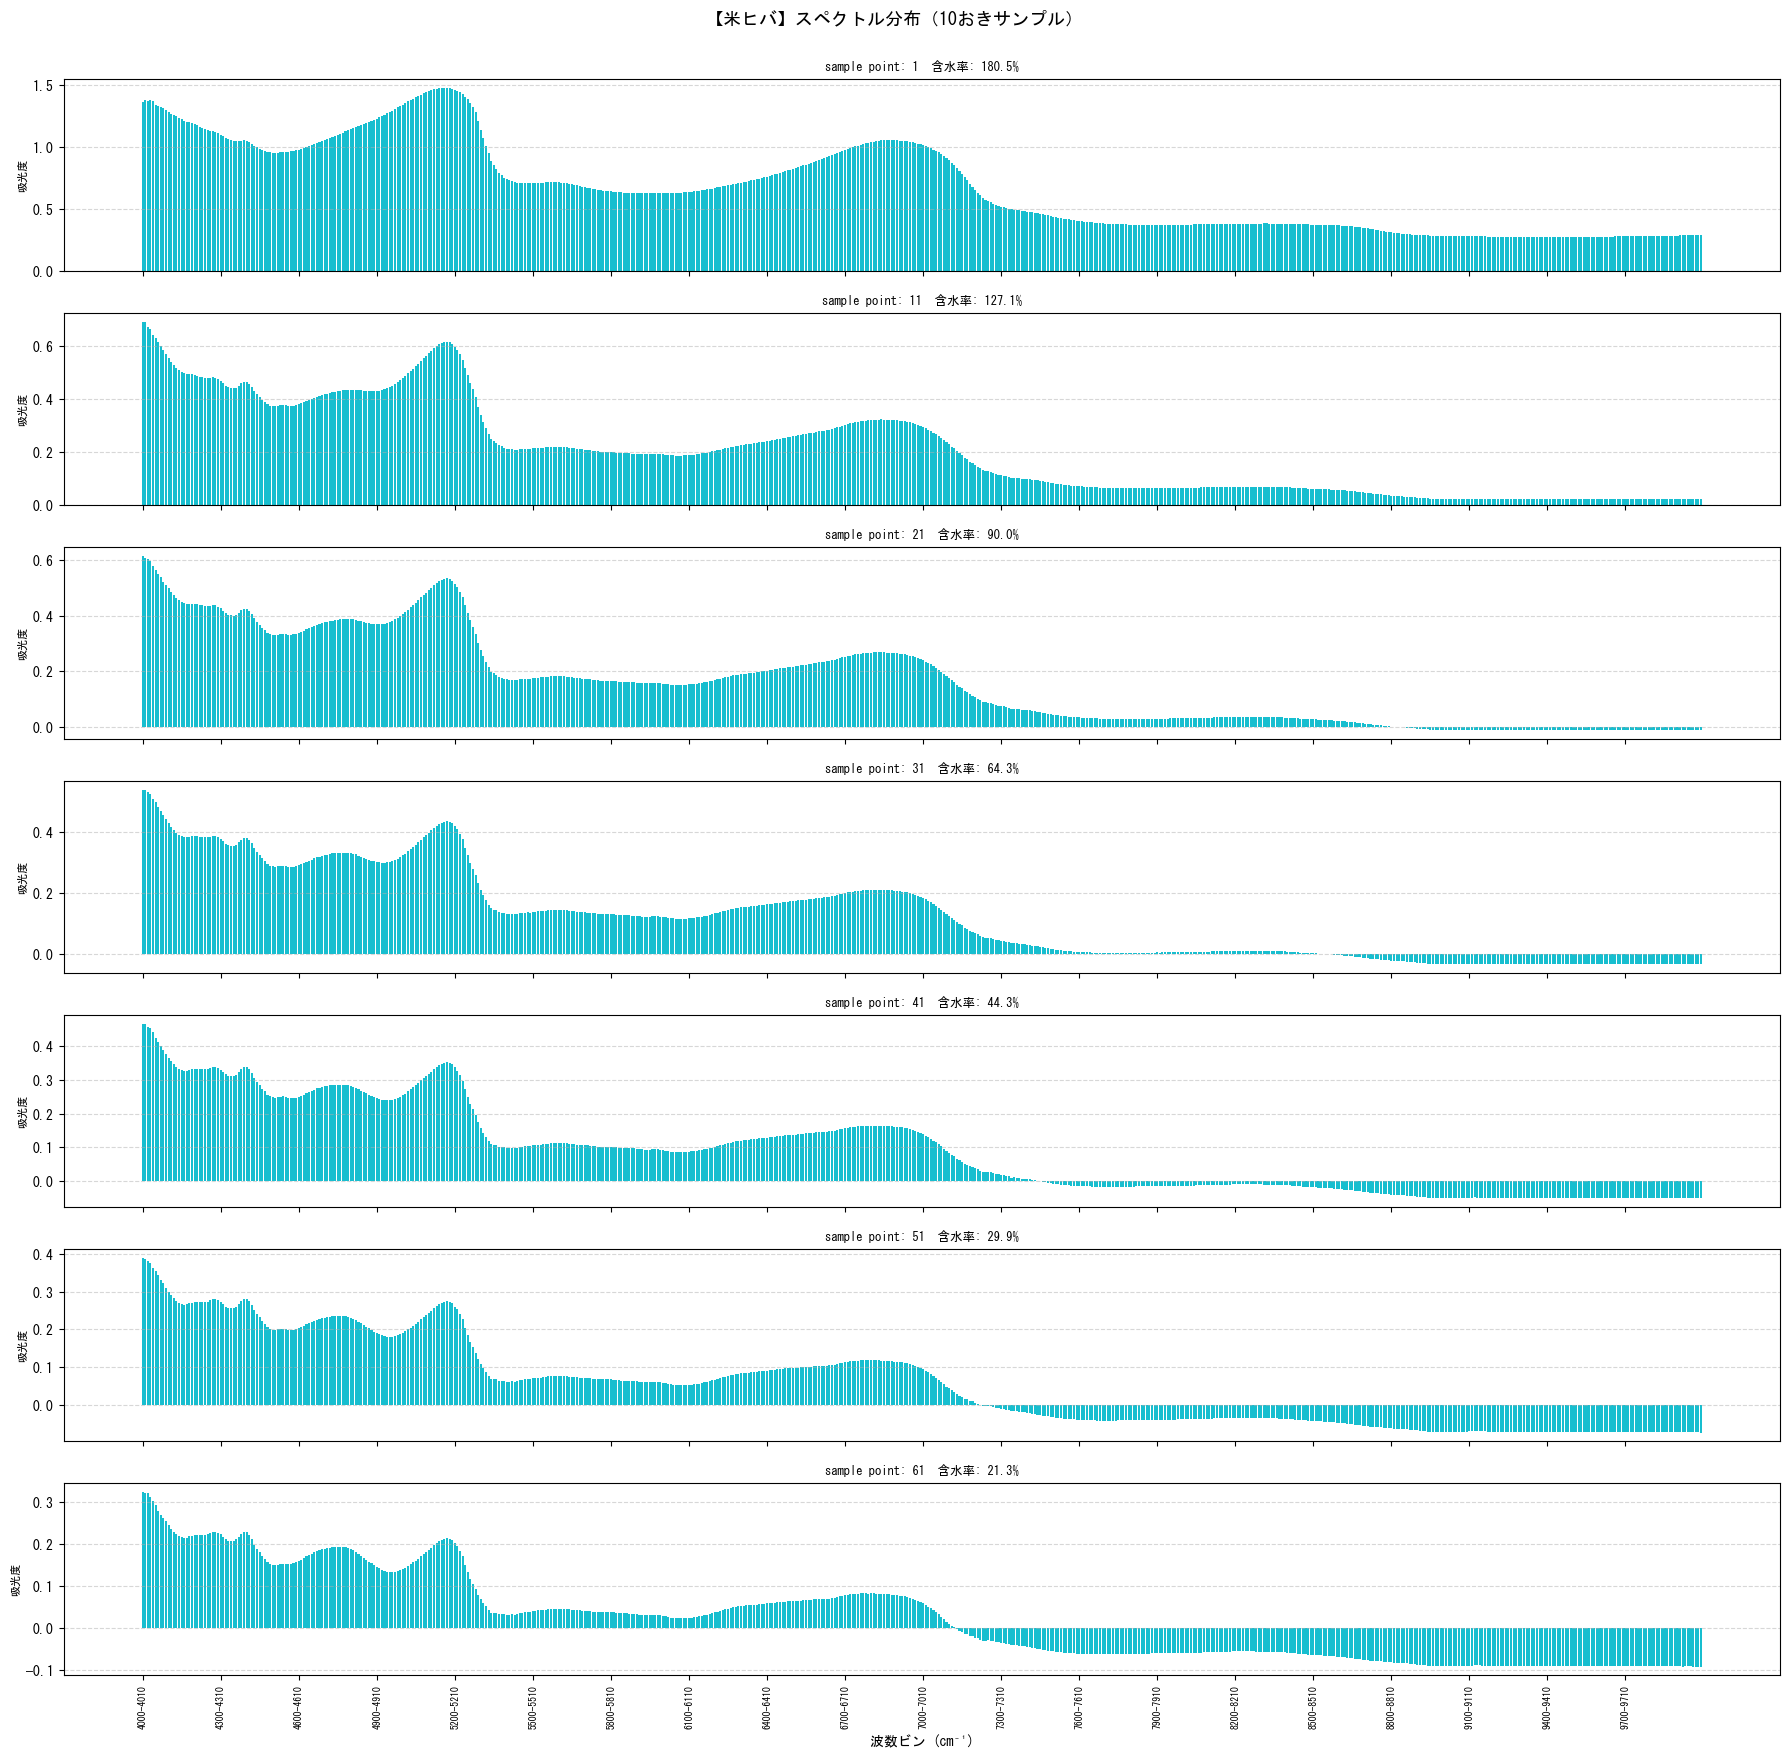

In [12]:

df_bin = pd.read_csv("data/spectrum_bin_mean.csv", encoding='utf-8-sig')

bin_cols = [c for c in df_bin.columns if c not in ['sample number', 'species number', '樹種', '含水率']]
species_list_sorted = sorted(df_bin['樹種'].unique())

# 樹種ごとの色
cmap = plt.get_cmap('tab20')
color_map = {sp: cmap(i / len(species_list_sorted)) for i, sp in enumerate(species_list_sorted)}

for species in species_list_sorted:
    subset = df_bin[df_bin['樹種'] == species].sort_values('sample number').reset_index(drop=True)
    # 樹種内の連番（1始まり）を付与
    subset['point'] = subset.index + 1
    # 10おきに間引き（1, 11, 21...番目）
    sampled = subset.iloc[::10]

    n_rows = len(sampled)
    fig, axes = plt.subplots(n_rows, 1, figsize=(18, n_rows * 2.5), sharex=True)
    if n_rows == 1:
        axes = [axes]

    color = color_map[species]
    for ax, (_, row) in zip(axes, sampled.iterrows()):
        ax.bar(bin_cols, row[bin_cols].values, color=color, width=0.8)
        ax.set_ylabel('吸光度', fontsize=8)
        ax.set_title(f"sample point: {int(row['point'])}  含水率: {row['含水率']:.1f}%", fontsize=9)
        ax.grid(axis='y', linestyle='--', alpha=0.5)

    axes[-1].set_xlabel('波数ビン (cm⁻¹)')
    tick_step = max(1, len(bin_cols) // 20)
    axes[-1].set_xticks(range(0, len(bin_cols), tick_step))
    axes[-1].set_xticklabels(bin_cols[::tick_step], rotation=90, fontsize=7)

    fig.suptitle(f'【{species}】スペクトル分布（10おきサンプル）', fontsize=13, y=1.002)
    plt.tight_layout()
    plt.show()


In [13]:
1+1

2

In [14]:
2+2

4